# Asteroid orbit optimization with PyGMO - Optimization - sphericsl harmonics
Copyright (c) 2010-2022, Delft University of Technology. All rights reserved. This file is part of the Tudat. Redistribution  and use in source and binary forms, with or without modification, are permitted exclusively under the terms of the Modified BSD license. You should have received a copy of the license with this file. If not, please or visit: http://tudat.tudelft.nl/LICENSE.

## Objectives
This tutorial is the third part of the Asteroid Orbit Optimization example. **This page reuses the** [Custom environment](aoo_custom_environment.ipynb) **part of the example, without the explanation, after which an optimization is executed.**

## Problem recap
This aim of this tutorial is to illustrate the use of PyGMO to optimize an astrodynamics problem simulated with tudatpy. The problem describes the orbit design around a small body, the [Themis asteroid](https://en.wikipedia.org/wiki/25143_Themis).

The 4 design variables are:

- initial values of the semi-major axis.
- initial eccentricity.
- initial inclination.
- initial longitude of the ascending node.
 
The 2 objectives are:

- good coverage (maximizing the mean value of the absolute longitude w.r.t. Themis over the full propagation).
- good resolution (the mean value of the distance should be minimized).
 
The constraints are set on the altitude: all the sets of design variables leading to an orbit.

### NOTE
It is assumed that the reader of this tutorial is already familiar with the content of [this basic PyGMO tutorial](https://docs.tudat.space/en/latest/_src_advanced_topics/optimization_pygmo.html). The full PyGMO documentation is available [on this website](https://esa.github.io/pygmo2/index.html). Be careful to read the
correct the documentation webpage (there is also a similar one for previous yet now outdated versions [here](https://esa.github.io/pygmo/index.html); as you can see, they can easily be confused).
PyGMO is the Python counterpart of [PAGMO](https://esa.github.io/pagmo2/index.html).

## Import statements

In [1]:
# Load standard modules
import os
import numpy as np
# Uncomment the following to make plots interactive
# %matplotlib widget
from matplotlib import pyplot as plt
from itertools import combinations as comb


# Load tudatpy modules
from tudatpy.data import save2txt
from tudatpy import constants
from tudatpy.interface import spice
from tudatpy.astro import element_conversion
from tudatpy.astro import frame_conversion
from tudatpy.dynamics import environment_setup
from tudatpy.dynamics import propagation_setup
from tudatpy.dynamics import simulator
import tudatpy.util as util

# Load pygmo library
import pygmo as pg

current_dir = os.path.abspath('')

## Creation of Custom Environment

### Themis rotation settings

In [2]:
def get_Themis_rotation_settings(Themis_body_frame_name):
    # Definition of initial Themis orientation conditions through the pole orientation
    pole_declination = np.deg2rad(59.8)     # Declination
    pole_right_ascension = np.deg2rad(125.6)  # Right ascension
    meridian_at_epoch = 0.0                   # Meridian

    # Define initial Themis orientation in inertial frame (equatorial plane)
    initial_orientation_j2000 = frame_conversion.inertial_to_body_fixed_rotation_matrix(
        pole_declination, pole_right_ascension, meridian_at_epoch)
    
    # Get initial Themis orientation in inertial frame but in the Ecliptic plane
    initial_orientation_eclipj2000 = np.matmul(spice.compute_rotation_matrix_between_frames(
        "J2000", "ECLIPJ2000", 0.0), initial_orientation_j2000)

    # Manually check the results, if desired
    check_results = False
    if check_results:
        np.set_printoptions(precision=100)
        print(initial_orientation_j2000)
    
        print(initial_orientation_eclipj2000)

    # Compute rotation rate
    # rotation_rate = np.deg2rad(712.143) / constants.JULIAN_DAY
    rotation_period = 8.374187 * 3600.0

    rotation_rate = 2.0 * np.pi / rotation_period

    # Set up rotational model for Themis with constant angular velocity
    return environment_setup.rotation_model.simple(
        "ECLIPJ2000", Themis_body_frame_name, initial_orientation_eclipj2000, 0.0, rotation_rate)

### Themis ephemeris settings

In [3]:
def get_Themis_ephemeris_settings(sun_gravitational_parameter):
    # Define Themis initial Kepler elements
    Themis_kepler_elements = np.array([
        3.1433 * constants.ASTRONOMICAL_UNIT,
        1.153499536381607E-01,
        np.deg2rad(7.366995500522935E-01),
        np.deg2rad(1.091193307580024E+02),
        np.deg2rad(3.639222711771391E+01),
        np.deg2rad(6.046711080424205E+01)])
    
    # Convert mean anomaly to true anomaly
    Themis_kepler_elements[5] = element_conversion.mean_to_true_anomaly(
        eccentricity=Themis_kepler_elements[1],
        mean_anomaly=Themis_kepler_elements[5])
    
    # Get epoch of initial Kepler elements (in Julian Days) 2025-Dec-12 00:00:00.0000
    kepler_elements_reference_julian_day = 2461021.5
    
    # Sets new reference epoch for Themis ephemerides (different from J2000)
    kepler_elements_reference_epoch = (kepler_elements_reference_julian_day - constants.JULIAN_DAY_ON_J2000) \
                                      * constants.JULIAN_DAY
    
    # Sets the ephemeris model
    return environment_setup.ephemeris.keplerian(
        Themis_kepler_elements,
        kepler_elements_reference_epoch,
        sun_gravitational_parameter,
        "Sun",
        "ECLIPJ2000")

### Themis gravity field settings

In [4]:
def get_Themis_gravity_field_settings(Themis_body_fixed_frame, Themis_radius):
    
    Themis_gravitational_parameter = 3.8e8  # m^3/s^2 — update if you have better value

    # 11x11 matrix → degrees 0-10, orders 0-10
    # Replace these with your actual data
    normalized_cosine_coefficients = np.array([
        [1.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=0
        [4.00437049323391e-10,      -2.00118621702933e-10,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=1
        [-0.0311484302600628, -0.00247282373836691,   -0.00274461339769334,  0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=2
        [-0.00200571383331492, -0.000432075164317321, 0.00194227892499834,0.00137270957639051, 0.0,    0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=3
        [0.00285332640564815,  0.00110182963502399, -0.000735718367676304, 0.000724745021813717, 0.00176998960899976, 0.0,   0.0,      0.0,      0.0,      0.0,      0.0],   # n=4
        [0.000830075337320937,      0.000287519798138761,      -0.000528107896235689,      -0.000867730821110781,      4.79023000648861e-05,      0.000879439295195050,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=5  ← your data
        [-0.000675558666706258,     -0.000205585971704600,      -0.000221135345635429,     -0.000318618655804238,      -0.000888434175048908,      -8.73422067817230e-05,     -0.000661361102590928,      0.0,      0.0,      0.0,      0.0],   # n=6
        [-0.000248341594690701,      -0.000163829109924533,      0.000232085380551457,      0.000258506065235110,      0.000160180230193337,      -0.000286377268939702,      6.77821275261500e-05,     0.000157407479968084,      0.0,      0.0,      0.0],   # n=7
        [0.000335217568650732,      -2.55140470111988e-05,      0.000274255269526383,      4.96324094064370e-05,      0.000342523466493208,     -1.86321450442635e-05,      0.000172675634502437,     9.50587862238274e-05,      0.000145987430976338,      0.0,      0.0],   # n=8
        [6.99720204690460e-05,      8.60097640010565e-05,      -0.000102732485716739,      -4.39268805337316e-05,      -0.000102645709362265,      0.000116936443373915,      -6.33826315277080e-05,      -5.20516633544555e-05,     -3.74472817959948e-05,      2.61212670888696e-05,      0.0],   # n=9
        [-0.000144111884090325,      2.32066521881085e-05,      -0.000126297847367392,      -2.62937726762541e-05,      -0.000124821278562081,      1.97212481561922e-05,      -4.97665457889904e-05,      -3.59202127991231e-05,      -7.28226920211166e-05,      1.23255404885492e-06,      -8.44844997134115e-05],   # n=10
    ])

    normalized_sine_coefficients = np.array([
        # m=0          m=1                        m=2                       m=3                       m=4                       m=5                       m=6                       m=7                       m=8                       m=9                       m=10
        [ 0.0,         0.0,                       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=0
        [ 0.0,        -1.12918257515491e-09,       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=1
        [ 0.0,         0.00107223359971325,       -0.00332663415194219,      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=2
        [ 0.0,        -0.00907886970678376,       -0.000235642226308041,    -0.00453797805800339,       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=3
        [ 0.0,        -0.000236332856522398,       0.000679356889179597,     0.00103902654905862,      -0.00164525397614147,      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=4
        [ 0.0,         0.00311673748224299,       -0.000197902324683847,     0.000723574770295993,     7.12712231701076e-05,      0.000728705277735932,      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=5
        [ 0.0,         9.08985833204355e-05,      -7.81012920836034e-05,    -0.000382933168574949,     0.000417670991355626,     -0.000244616302121161,     -0.000272475519450808,     0.0,                      0.0,                      0.0,                      0.0         ],  # n=6
        [ 0.0,        -0.000726023965052120,      -0.000157289026194778,    -0.000151049434293496,    -1.31229025167918e-05,     -0.000180291881759017,      4.75861083370220e-05,     -0.000466425371326853,     0.0,                      0.0,                      0.0         ],  # n=7
        [ 0.0,        -4.66199482564515e-05,       4.07552978692181e-05,     0.000141144082038173,    -7.01025270851237e-05,      3.48820998708198e-05,      9.78492071833127e-05,      2.78823107064210e-05,     -0.000108013182515871,     0.0,                      0.0         ],  # n=8
        [ 0.0,         0.000177445235331498,       0.000124031343956387,     0.000102169331575207,     3.03402767376233e-05,      0.000131791270134196,      1.21961070494812e-05,      0.000178265283377157,      3.51673248637755e-05,      4.88474288152410e-05,     0.0         ],  # n=9
        [ 0.0,         7.90100853753287e-06,      -1.42280089749264e-05,    -7.29562295080795e-05,     2.77916592967652e-06,     -2.60570209403151e-05,     -2.33055610543032e-05,     -2.66308045112190e-05,      2.55117509946166e-05,     -3.32601179349906e-05,    -3.94450492257997e-06],  # n=10
    ])
    # ← UNCOMMENT this and remove the central() call below
    return environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter=Themis_gravitational_parameter,
        reference_radius=Themis_radius,
        normalized_cosine_coefficients=normalized_cosine_coefficients,
        normalized_sine_coefficients=normalized_sine_coefficients,
        associated_reference_frame=Themis_body_fixed_frame)

    # ← REMOVE this line (was placeholder, ignores all SH structure)
    # return environment_setup.gravity_field.central(
    #     gravitational_parameter=Themis_gravitational_parameter)

### Themis shape settings

In [5]:
def get_Themis_shape_settings(Themis_radius):
    # Creates spherical shape settings
    return environment_setup.shape.spherical(Themis_radius)

### Simulation bodies

In [6]:
def create_simulation_bodies(Themis_radius):
    ### CELESTIAL BODIES ###
    # Define Themis body frame name
    Themis_body_frame_name = "Themis_Frame"

    # Create default body settings for selected celestial bodies
    bodies_to_create = ["Sun", "Earth", "Jupiter", "Saturn", "Mars"]

    # Create default body settings for bodies_to_create, with "Earth"/"J2000" as
    # global frame origin and orientation. This environment will only be valid
    # in the indicated time range [simulation_start_epoch --- simulation_end_epoch]
    body_settings = environment_setup.get_default_body_settings(
        bodies_to_create,
        "SSB",
        "ECLIPJ2000")

    # Add Themis body
    body_settings.add_empty_settings("Themis")

    # Adds Themis settings
    # Gravity field
    body_settings.get("Themis").gravity_field_settings = get_Themis_gravity_field_settings(Themis_body_frame_name,
                                                                        Themis_radius)
    # Rotational model
    body_settings.get("Themis").rotation_model_settings = get_Themis_rotation_settings(Themis_body_frame_name)
    # Ephemeris
    body_settings.get("Themis").ephemeris_settings = get_Themis_ephemeris_settings(
        spice.get_body_gravitational_parameter( 'Sun') )
    # Shape (spherical)
    body_settings.get("Themis").shape_settings = get_Themis_shape_settings(Themis_radius)

    ### VEHICLE BODY ###
    # Create vehicle object
    body_settings.add_empty_settings("Spacecraft")
    body_settings.get("Spacecraft").constant_mass = 986 # mass latest

    # Create radiation pressure settings
    reference_area_radiation = 65+2.4*2.2  # talked with structure team
    radiation_pressure_coefficient = 1.2
    occulting_bodies_dict = dict()
    occulting_bodies_dict["Sun"] = ["Themis"]
    vehicle_target_settings = environment_setup.radiation_pressure.cannonball_radiation_target(
        reference_area_radiation, radiation_pressure_coefficient, occulting_bodies_dict )

    # Add the radiation pressure interface to the body settings
    body_settings.get("Spacecraft").radiation_pressure_target_settings = vehicle_target_settings

    # Create system of selected bodies
    bodies = environment_setup.create_system_of_bodies(body_settings)

    return bodies

### Acceleration models

In [7]:
def get_acceleration_models(bodies_to_propagate, central_bodies, bodies):
    # Define accelerations acting on Spacecraft
    accelerations_settings_spacecraft = dict(
        Sun =     [ propagation_setup.acceleration.radiation_pressure(),
                    propagation_setup.acceleration.point_mass_gravity() ],
        Themis = [ propagation_setup.acceleration.spherical_harmonic_gravity(10, 10) ],
        Jupiter = [ propagation_setup.acceleration.point_mass_gravity() ],
        Saturn =  [ propagation_setup.acceleration.point_mass_gravity() ],
        Mars =    [ propagation_setup.acceleration.point_mass_gravity() ],
        Earth =   [ propagation_setup.acceleration.point_mass_gravity() ]
    )

    # Create global accelerations settings dictionary
    acceleration_settings = {"Spacecraft": accelerations_settings_spacecraft}

    # Create acceleration models
    return propagation_setup.create_acceleration_models(
        bodies,
        acceleration_settings,
        bodies_to_propagate,
        central_bodies)

### Termination settings

In [8]:
def get_termination_settings(mission_initial_time, 
                             mission_duration,
                             minimum_distance_from_com,
                             maximum_distance_from_com):
    # Mission duration
    time_termination_settings = propagation_setup.propagator.time_termination(
        mission_initial_time + mission_duration,
        terminate_exactly_on_final_condition=False
    )
    # Upper altitude
    upper_altitude_termination_settings = propagation_setup.propagator.dependent_variable_termination(
        dependent_variable_settings=propagation_setup.dependent_variable.relative_distance('Spacecraft', 'Themis'),
        limit_value=maximum_distance_from_com,
        use_as_lower_limit=False,
        terminate_exactly_on_final_condition=False
    )
    # Lower altitude
    lower_altitude_termination_settings = propagation_setup.propagator.dependent_variable_termination(
        dependent_variable_settings=propagation_setup.dependent_variable.relative_distance('Spacecraft', 'Themis'),
        limit_value=minimum_distance_from_com,
        use_as_lower_limit=True,
        terminate_exactly_on_final_condition=False
    )

    # Define list of termination settings
    termination_settings_list = [time_termination_settings,
                                 upper_altitude_termination_settings,
                                 lower_altitude_termination_settings]

    return propagation_setup.propagator.hybrid_termination(termination_settings_list,
                                                           fulfill_single_condition=True)

### Dependent variables to save

In [9]:
# =============================================================================
# SECTION 1 — MODIFIED: Dependent variables to save
# =============================================================================
# Added keplerian_state so we can track semi-major axis variation in-flight.
# Output column layout for dep_var_array:
#   col 0   → radial distance from Themis CoM  [m]        ← from spherical pos
#   col 1   → latitude (body-fixed)             [rad]      ← from spherical pos
#   col 2   → longitude (body-fixed)            [rad]      ← from spherical pos
#   col 3   → semi-major axis  a                [m]        ← from keplerian_state
#   col 4   → eccentricity     e                [-]
#   col 5   → inclination      i                [rad]
#   col 6   → arg of periapsis ω                [rad]
#   col 7   → RAAN             Ω                [rad]
#   col 8   → true anomaly     ν                [rad]
 
def get_dependent_variables_to_save():
    return [
        propagation_setup.dependent_variable.central_body_fixed_spherical_position(
            "Spacecraft", "Themis"),                     # cols 0-2
        propagation_setup.dependent_variable.keplerian_state(
            "Spacecraft", "Themis"),                     # cols 3-8
    ]
    return dependent_variables_to_save

## Optimisation problem formulation 

In [10]:
class AsteroidOrbitProblem:
 
    def __init__(self,
                 bodies,
                 propagator_settings,
                 mission_initial_time,
                 mission_duration,
                 design_variable_lower_boundaries,
                 design_variable_upper_boundaries,
                 Themis_radius,
                 lat_bins=18,     # 10° per bin  (18 × 10° = 180°)
                 lon_bins=36):    # 10° per bin  (36 × 10° = 360°)
 
        self.bodies_function              = lambda: bodies
        self.propagator_settings_function = lambda: propagator_settings
        self.dynamics_simulator_function  = lambda: None
 
        self.mission_initial_time         = mission_initial_time
        self.mission_duration             = mission_duration
        self.mission_final_time           = mission_initial_time + mission_duration
        self.design_variable_lower_boundaries = design_variable_lower_boundaries
        self.design_variable_upper_boundaries = design_variable_upper_boundaries
        self.Themis_radius                = Themis_radius
 
        # ── Precompute coverage grid cell areas ────────────────────────────
        # Exact spherical-strip formula:
        #   area of one cell = R² × |sin(lat_hi) - sin(lat_lo)| × Δlon
        # Normalised by R² so total ≈ 4π; we divide by total at the end.
        self.lat_bins = lat_bins
        self.lon_bins = lon_bins
 
        lat_edges = np.linspace(-np.pi / 2, np.pi / 2, lat_bins + 1)
        lon_edges = np.linspace(-np.pi, np.pi, lon_bins + 1)
        delta_lon = 2 * np.pi / lon_bins
 
        # cell_areas[i, j] = area of cell (lat-strip i, lon-strip j)  [R² units]
        lat_strip_areas   = np.diff(np.sin(lat_edges)) * delta_lon   # shape (lat_bins,)
        self.cell_areas   = np.outer(lat_strip_areas,
                                     np.ones(lon_bins))               # (lat_bins, lon_bins)
        self.total_surface = np.sum(self.cell_areas)                  # ≈ 4π
 
        # Bin edge arrays stored for fast searchsorted indexing
        self.lat_edges = lat_edges
        self.lon_edges = lon_edges
 
    # ── bounds ────────────────────────────────────────────────────────────────
    def get_bounds(self):
        return (list(self.design_variable_lower_boundaries),
                list(self.design_variable_upper_boundaries))
 
    # ── CHANGED: 2 objectives ─────────────────────────────────────────────────
    def get_nobj(self):
        return 2
 
    # ── CHANGED: fitness ──────────────────────────────────────────────────────
    def fitness(self, orbit_parameters):
 
        current_bodies                = self.bodies_function()
        Themis_gravitational_parameter = current_bodies.get("Themis").gravitational_parameter
 
        # Convert design variables → Cartesian initial state
        new_initial_state = element_conversion.keplerian_to_cartesian_elementwise(
            gravitational_parameter     = Themis_gravitational_parameter,
            semi_major_axis             = orbit_parameters[0],
            eccentricity                = orbit_parameters[1],
            inclination                 = np.deg2rad(orbit_parameters[2]),
            argument_of_periapsis       = np.deg2rad(235.7),
            longitude_of_ascending_node = np.deg2rad(orbit_parameters[3]),
            true_anomaly                = np.deg2rad(139.87))
 
        propagator_settings = self.propagator_settings_function()
        propagator_settings.initial_states = new_initial_state
 
        # Run propagation
        dynamics_simulator = simulator.create_dynamics_simulator(
            current_bodies, propagator_settings)
        self.dynamics_simulator_function = lambda: dynamics_simulator
 
        dep_hist = dynamics_simulator.propagation_results.dependent_variable_history
 
        # ── Propagation failed at t=0 ─────────────────────────────────────────
        if len(dep_hist) < 2:
            return [1.0, 1.0]   # worst possible for both objectives
 
        dep_arr  = np.vstack(list(dep_hist.values()))   # (N, 9)
        latitudes  = dep_arr[:, 1]   # rad
        longitudes = dep_arr[:, 2]   # rad
        sma_history = dep_arr[:, 3]  # semi-major axis [m]  (col 3 = keplerian a)
 
        # ── Survival fraction (smooth penalty) ────────────────────────────────
        actual_final_time = max(dep_hist.keys())
        survival_fraction = min(
            (actual_final_time - self.mission_initial_time) / self.mission_duration,
            1.0)
 
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # OBJECTIVE 1 — Coverage  =  area captured / total Themis surface area
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # Map each observation to a (lat-bin, lon-bin) grid cell
        lat_idx = np.clip(
            np.searchsorted(self.lat_edges[1:], latitudes),
            0, self.lat_bins - 1)
        lon_idx = np.clip(
            np.searchsorted(self.lon_edges[1:], longitudes),
            0, self.lon_bins - 1)
 
        # Boolean coverage grid — mark every cell ever visited
        coverage_grid = np.zeros((self.lat_bins, self.lon_bins), dtype=bool)
        coverage_grid[lat_idx, lon_idx] = True
 
        # Sum the exact spherical areas of visited cells
        covered_area     = np.sum(self.cell_areas[coverage_grid])
        coverage_fraction = covered_area / self.total_surface   # in [0, 1]
 
        # Apply survival penalty: if orbit dies early, only that fraction counts
        # (an orbit that crashes after 10 days should not get credit for 100-day coverage)
        effective_coverage = coverage_fraction * survival_fraction
 
        # Minimise → negate
        obj_coverage = 1.0 - effective_coverage   # 0 = perfect, 1 = no coverage
 
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # OBJECTIVE 2 — Stability  =  std(a) / mean(a)   (coefficient of variation)
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # A perfectly stable circular orbit has Δa = 0.
        # Gravitational perturbations and 3rd-body forces cause a to drift.
        # We minimise the normalised variation so the metric is orbit-size agnostic.
        if len(sma_history) > 1:
            delta_a = np.std(sma_history) / np.mean(sma_history)
        else:
            delta_a = 1.0
 
        # Apply survival penalty: an orbit that crashes in 5 days trivially has
        # low Δa — inflate the stability cost proportionally to encourage survival.
        obj_stability = delta_a / survival_fraction   # large if crashed early
 
        return [obj_coverage, obj_stability]
 
    def get_last_run_dynamics_simulator(self):
        return self.dynamics_simulator_function()

### Setup orbital simulation


#### Simulation settings

In [11]:
# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs
# mission_initial_time = 0.0
from tudatpy.astro.time_representation import DateTime

mission_initial_time = DateTime(
    2041, 12, 12, 19, 23, 12
).epoch()
mission_duration = 100.0 * constants.JULIAN_DAY

# Define Themis radius
Themis_radius = 99*1000

# Set altitude termination conditions
minimum_distance_from_com = 10.0E3 + Themis_radius
maximum_distance_from_com = 550.0E3 + Themis_radius

# Set boundaries on the design variables
design_variable_lb = (160000.0, 0.0, 0.0, 0.0)
design_variable_ub = (180000.0, 0.15, 180, 360)

# Create simulation bodies
bodies = create_simulation_bodies(Themis_radius)

# Define bodies to propagate and central bodies
bodies_to_propagate = ["Spacecraft"]
central_bodies = ["Themis"]

# Create acceleration models
acceleration_models = get_acceleration_models(bodies_to_propagate, central_bodies, bodies)

#### Dependent variables, termination settings, and orbit parameters

In [12]:
# Define list of dependent variables to save
dependent_variables_to_save = get_dependent_variables_to_save()

# Create propagation settings
termination_settings = get_termination_settings(
    mission_initial_time, mission_duration, minimum_distance_from_com, maximum_distance_from_com)

orbit_parameters = [1.20940330e+03, 2.61526215e-01, 7.53126558e+01, 2.60280587e+02]

#### Integrator and Propagator settings

In [13]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    initial_time_step=1.0,
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78,
    minimum_step_size=1.0E-6,
    maximum_step_size=constants.JULIAN_DAY,
    relative_error_tolerance=1.0E-8,
    absolute_error_tolerance=1.0E-8)

# Get current propagator, and define translational state propagation settings
propagator = propagation_setup.propagator.cowell
# Define propagation settings
initial_state = np.zeros(6)
propagator_settings = propagation_setup.propagator.translational(central_bodies,
                                                                         acceleration_models,
                                                                         bodies_to_propagate,
                                                                         initial_state,
                                                                         mission_initial_time,
                                                                         integrator_settings,
                                                                         termination_settings,
                                                                         propagator,
                                                                         dependent_variables_to_save)

## Optimisation run

**From here on out the example is new compared to the** [Custom environment](aoo_custom_environment.ipynb) **part of the example.**

With the optimization problem and the simulation setup in hand, let's now run our optimization using PyGMO.

### Algorithm and problem definition
First, we define a fixed seed that PyGMO will use to generate random numbers. This ensures that the results can be reproduced. 

Then, the optimization problem is defined using the `AsteroidOrbitProblem` class initiated with the values that have already been defined. This User Defined Problem (UDP) is then given to PyGMO trough the `pg.problem()` method.

Finally, the optimizer is selected to be the Multi-objective EA with Decomposition (MOAD) algorithm that is implemented in PyGMO. See [here](https://esa.github.io/pygmo2/algorithms.html#pygmo.moead) for its documentation.

In [14]:
# Fix seed for reproducibility
fixed_seed = 112987

# Instantiate orbit problem
orbitProblem = AsteroidOrbitProblem(
    bodies,
    propagator_settings,
    mission_initial_time,
    mission_duration,
    design_variable_lb,
    design_variable_ub,
    Themis_radius,
    lat_bins=18,    # 10° latitude resolution
    lon_bins=36)    # 10° longitude resolution

# Create pygmo problem using the UDP instantiated above
prob = pg.problem(orbitProblem)

# Select Moead algorithm from pygmo, with one generation
algo = pg.algorithm(pg.nsga2(gen=1, seed=fixed_seed))

### Initial population
An initial population is now going to be generated by PyGMO, of a size of 48 individuals. This means that 48 orbital simulations will be run, and the fitness corresponding to the 48 individuals will be computed using the UDP.

In [15]:
# Initialize pygmo population with 48 individuals
population_size = 72
pop = pg.population(prob, size=population_size, seed=fixed_seed)

### Evolve population
We now want to make this population evolve, as to (hopefully) get closer to optimum solutions.

In a loop, we thus call `algo.evolve(pop)` 25 times to make the population evolve 25 times. During each generation, we also save the list of fitness and of design variables.

In [16]:
# Set the number of evolutions
number_of_evolutions = 60

# Initialize containers
fitness_list = []
population_list = []

# Evolve the population recursively
for gen in range(number_of_evolutions):
    # print("Evolving population; at generation %i/%i" % (gen, number_of_evolutions-1))
    
    # Evolve the population
    pop = algo.evolve(pop)
    
    # Store the fitness values and design variables for all individuals
    fitness_list.append(pop.get_f())
    population_list.append(pop.get_x())
    if (gen + 1) % 5 == 0:
        pareto_mask = util.pareto_optimums(pop.get_f())
        n_pareto    = np.sum(pareto_mask)
        best_cov    = 1.0 - np.min(pop.get_f()[pareto_mask, 0])
        print(f"  Gen {gen+1:3d}/{number_of_evolutions} | "
              f"Pareto front size: {n_pareto:2d} | "
              f"Best coverage: {best_cov*100:.1f}%")

    
print("Evolving population is finished!")

  Gen   5/60 | Pareto front size: 54 | Best coverage: 100.0%
  Gen  10/60 | Pareto front size: 66 | Best coverage: 100.0%
  Gen  15/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  20/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  25/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  30/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  35/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  40/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  45/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  50/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  55/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  60/60 | Pareto front size: 72 | Best coverage: 100.0%
Evolving population is finished!


### Results analysis
With the population evolved, the optimization is finished. We can now analyse the results to see how our optimization was carried, and what our optimum solutions are.

#### Extract results
First of, we want to save the state and dependent variable history of the orbital simulations that were carried in the first and last generations. To do so, we extract the design variables of all the member of a given population, and we run the orbital simulation again, calling the `orbitProblem.fitness()` function. Then, we can extract the state and dependent variable history by calling the `orbitProblem.get_last_run_dynamics_simulator()` function.

In [17]:
# Retrieve first and last generations for further analysis
pops_to_analyze = {0: 'initial',
                   number_of_evolutions - 1 : 'final'}

# Initialize containers
simulation_output = dict()

# Loop over first and last generations
for population_index, population_name in pops_to_analyze.items():
    
    # Get population individuals from the given generation
    current_population = population_list[population_index]
    
    # Current generation's dictionary
    generation_output = dict()
    
    # Loop over all individuals of the populations
    for individual in range(population_size):

        # Retrieve orbital parameters
        current_orbit_parameters = current_population[individual]
        
        # Propagate orbit and compute fitness
        orbitProblem.fitness(current_orbit_parameters)
        
        # Retrieve state and dependent variable history
        current_states = orbitProblem.get_last_run_dynamics_simulator().propagation_results.state_history
        current_dependent_variables = orbitProblem.get_last_run_dynamics_simulator().propagation_results.dependent_variable_history
        
        # Save results to dict
        generation_output[individual] = [current_states, current_dependent_variables]
        
    # Append to global dictionary
    simulation_output[population_index] = [generation_output,
                                           fitness_list[population_index],
                                           population_list[population_index]]

#### Pareto fronts
As a first analysis of the optimization results, let's plot the Pareto fronts, to represent the optimums.

This is done for the first and last generation, plotting the score of the two objectives for all of the population members. A colormap is also used to represent the value of the design variables selected by the optimiser. Finally, the Pareto front is plotted in green, showing the limit of the attainable optimum solutions. 


These Pareto fronts show that both of the objectives were successfully improved after 25 generations, attaining lower values for both of them.

We can also notice that the population is packed closer to the Pareto front after 25 generations. At the opposite, the population was covering a higher area of the design space for the first generation.

In [18]:
# Create dictionaries defining the design variables
design_variable_names = {0: 'Semi-major axis [m]',
                           1: 'Eccentricity',
                           2: 'Inclination [deg]',
                           3: 'Longitude of the node [deg]'}
design_variable_range = {0: [110000.0, 250000.0],
                           1: [0.0, 0.3],
                           2: [0, 180.0],
                           3: [0, 360.0]}
design_variable_symbols = {0: r'$a$',
                             1: r'$e$',
                             2: r'$i$',
                             3: r'$\Omega$'}
design_variable_units = {0: r' m',
                           1: r' ',
                           2: r' deg',
                           3: r' deg'}

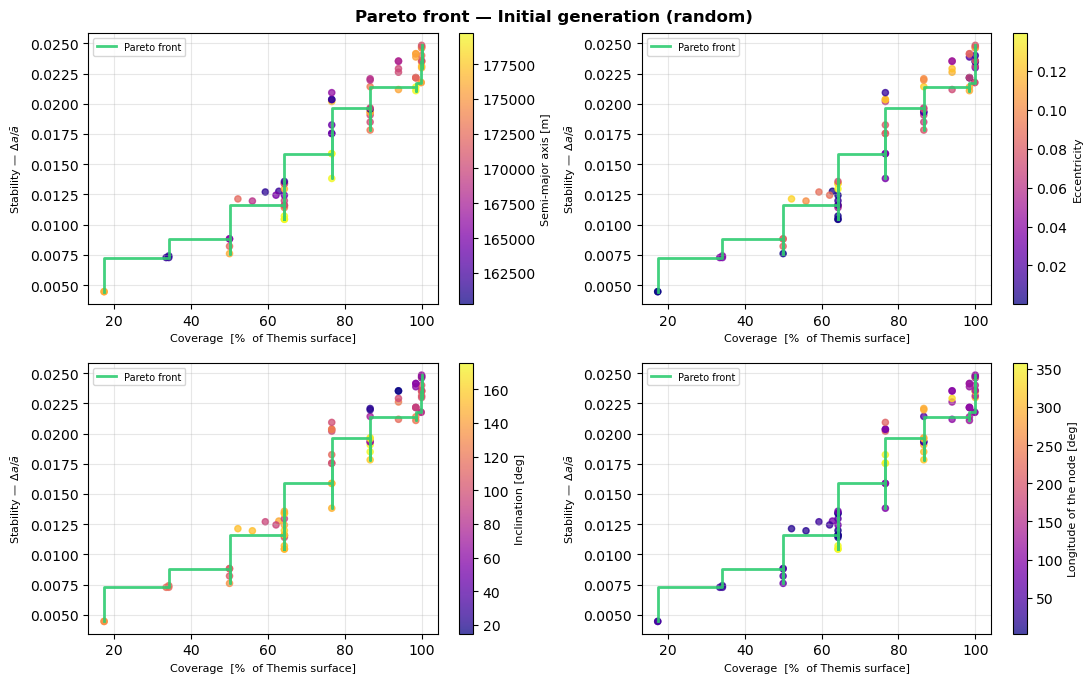

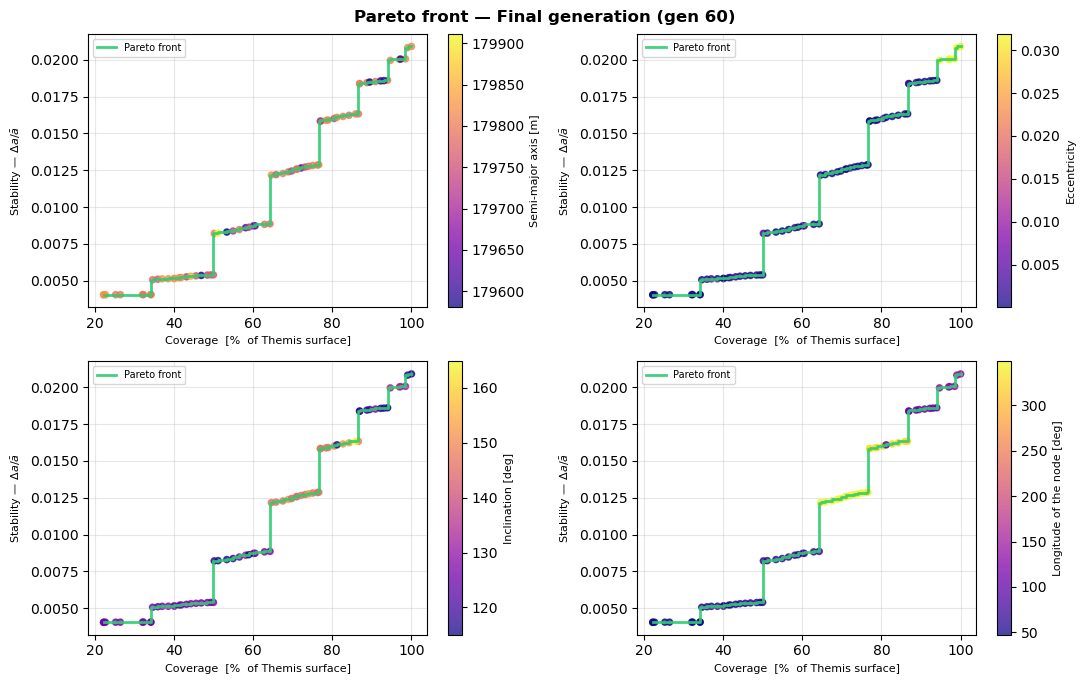

In [19]:
for population_index in simulation_output.keys():
    current_generation = simulation_output[population_index]
    current_fitness    = current_generation[1]    # shape (pop_size, 2)
    current_population = current_generation[2]    # shape (pop_size, 4)
 
    gen_label = 'Initial generation (random)' \
        if population_index == 0 \
        else f'Final generation (gen {number_of_evolutions})'
 
    # Convert objective 1 back to readable coverage %
    coverage_pct  = (1.0 - current_fitness[:, 0]) * 100   # [%]
    stability_cv  = current_fitness[:, 1]                  # normalised Δa
 
    fig, axs = plt.subplots(2, 2, figsize=(11, 7))
    fig.suptitle(f'Pareto front — {gen_label}', fontweight='bold', y=0.97)
 
    for ax_index, ax in enumerate(axs.flatten()):
        cs = ax.scatter(coverage_pct,
                        stability_cv,
                        c      = current_population[:, ax_index],
                        s      = 80,
                        marker = '.',
                        cmap   = 'plasma',
                        alpha  = 0.75)
        cbar = fig.colorbar(cs, ax=ax)
        cbar.ax.set_ylabel(design_variable_names[ax_index], fontsize=8)
 
        # Pareto front line
        pareto_mask = util.pareto_optimums(current_fitness)
        pareto_cov  = coverage_pct[pareto_mask]
        pareto_sta  = stability_cv[pareto_mask]
        sort_idx    = np.argsort(pareto_cov)
        ax.step(pareto_cov[sort_idx], pareto_sta[sort_idx],
                color='#2ecc71', linewidth=2, alpha=0.9, label='Pareto front')
 
        ax.set_xlabel('Coverage  [%  of Themis surface]', fontsize=8)
        ax.set_ylabel(r'Stability — $\Delta a / \bar{a}$', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
 
    plt.tight_layout()
    plt.show()

#### Design variables histogram
Plotting the histogram of the design variables for the final generation gives insights into what set of orbital parameters lead to optimum solutions. Possible optimum design variables values can then be detected by looking at the number of population members that use them. A high number of occurrences in the final generation **could** indicate a better design variable. At least, this offers some leads into what to investigate further.

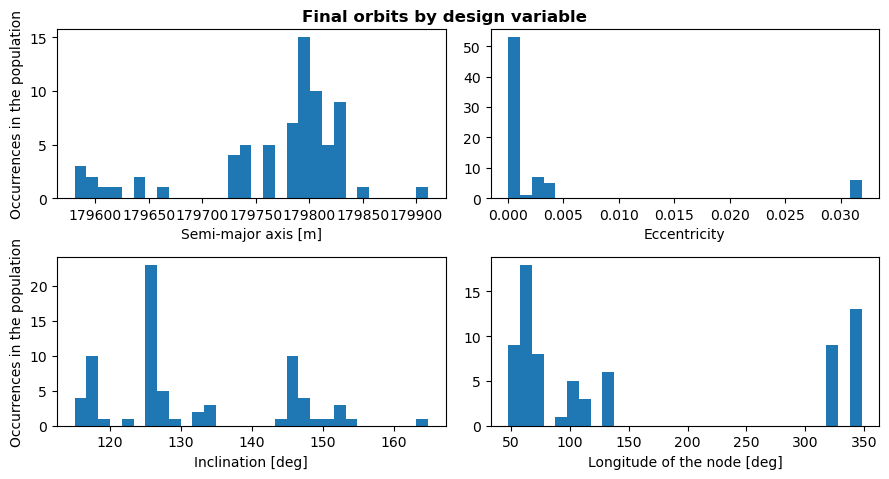

In [20]:
# Plot histogram for last generation, semi-major axis
fig, axs = plt.subplots(2, 2, figsize=(9, 5))
fig.suptitle('Final orbits by design variable', fontweight='bold', y=0.95)
last_pop = simulation_output[number_of_evolutions - 1][2]

for ax_index, ax in enumerate(axs.flatten()):
    ax.hist(last_pop[:, ax_index], bins=30)
    
    # Prettify
    ax.set_xlabel(design_variable_names[ax_index])
    if ax_index % 2 == 0:
        ax.set_ylabel('Occurrences in the population')
        
# Show the figure
plt.tight_layout()
plt.show()

#### Initial and final orbits visualisation
One may now want to see how much better the optimized orbits are compared to the ones of the random initial population. This can be done by plotting the orbit bundles from the initial and final generations.

The resulting 3D plot show the chaotic nature of the initial random population, where the last generation appears to use a handfull of variations of the similar design variables.

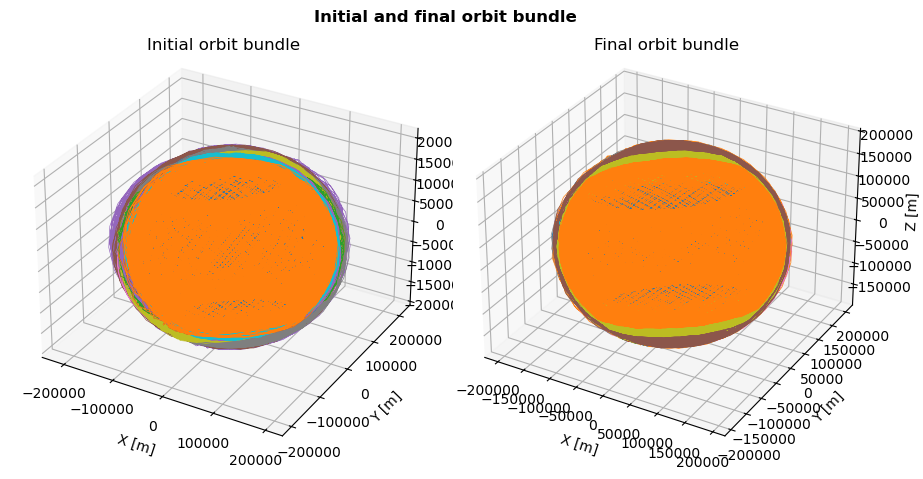

In [21]:
# Plot orbits of initial and final generation
fig = plt.figure(figsize=(9, 5))
fig.suptitle('Initial and final orbit bundle', fontweight='bold', y=0.95)
title = {0: 'Initial orbit bundle',
         1: 'Final orbit bundle'}

# Loop over populations
for ax_index, population_index in enumerate(simulation_output.keys()):
    current_ax = fig.add_subplot(1, 2, 1 + ax_index, projection='3d')
    
    # Retrieve current population
    current_generation = simulation_output[population_index]
    current_population = current_generation[2]
    
    # Loop over individuals
    for ind_index, individual in enumerate(current_population):
        
        # Plot orbit
        state_history = list(current_generation[0][ind_index][0].values())
        state_history = np.vstack(state_history)
        current_ax.plot(state_history[:, 0],
                        state_history[:, 1],
                        state_history[:, 2],
                        linewidth=0.5)
        
    # Prettify
    current_ax.set_xlabel('X [m]')
    current_ax.set_ylabel('Y [m]')
    current_ax.set_zlabel('Z [m]')
    current_ax.set_title(title[ax_index], y=1.0, pad=15)

# Show the figure
plt.tight_layout()
plt.show()

#### Orbits visualization by design variable
Finally, we can visualize what range of design variables lead to which type of orbits. This is done by plotting the bundle of orbits for the last generation.

This plot one again shows that the orbits from the final population can be sub-categorized into distinct orbital configurations.


── Knee-point (best trade-off) orbit ───────────────────────────
  Coverage (area/total) : 64.3%
  Stability  Δa/mean(a) : 8.8578e-03
  Semi-major axis       : 179.79 km
  Eccentricity          : 0.0002
  Inclination           : 127.49 deg
  RAAN                  : 74.09 deg
────────────────────────────────────────────────────────────────

Propagating best (knee-point) orbit for visualisation...


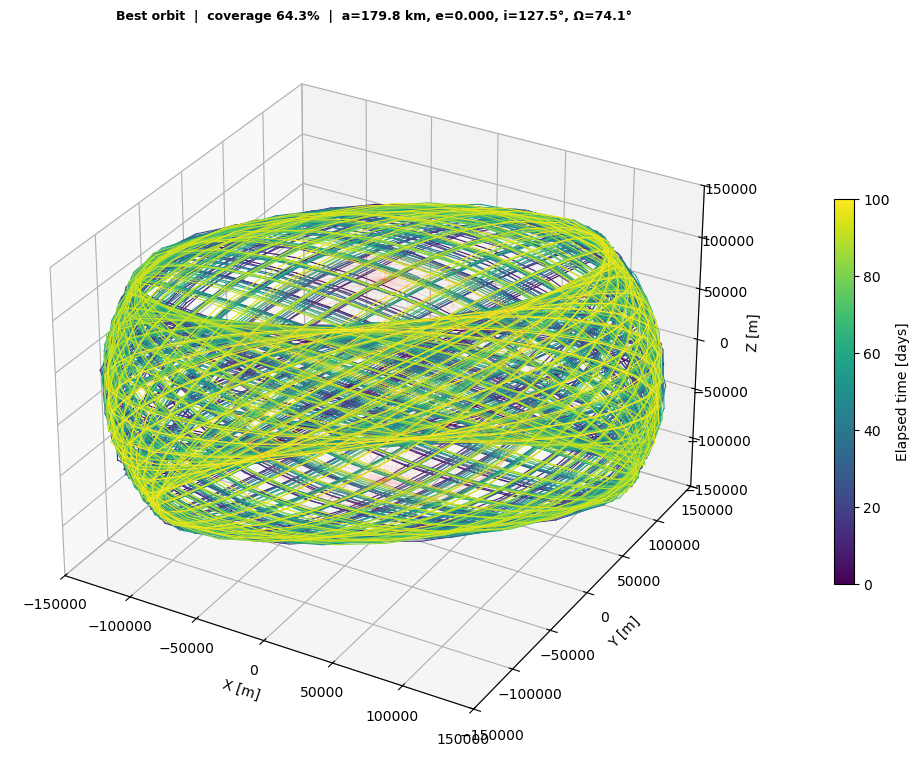

In [22]:
# =============================================================================
# SECTION 9 — SELECT BEST ORBIT FROM PARETO FRONT  (knee-point method)
# =============================================================================
# The "knee point" is the Pareto-optimal solution that is closest to the
# ideal point (0, 0) in normalised objective space — it gives the best
# simultaneous trade-off between coverage and stability.
 
final_fitness     = fitness_list[-1]          # (pop_size, 2)
final_population  = population_list[-1]
 
pareto_mask   = util.pareto_optimums(final_fitness)
pareto_fitness = final_fitness[pareto_mask]   # (n_pareto, 2)
pareto_params  = final_population[pareto_mask]
 
# Normalise each objective to [0, 1]
obj_min = pareto_fitness.min(axis=0)
obj_max = pareto_fitness.max(axis=0)
obj_range = obj_max - obj_min + 1e-12         # avoid division by zero
 
pareto_normalised = (pareto_fitness - obj_min) / obj_range
 
# Euclidean distance from ideal point (0, 0) in normalised space
dist_to_ideal = np.linalg.norm(pareto_normalised, axis=1)
knee_idx      = np.argmin(dist_to_ideal)
 
best_params          = pareto_params[knee_idx]
best_fitness         = pareto_fitness[knee_idx]
best_coverage_pct    = (1.0 - best_fitness[0]) * 100
best_stability_cv    = best_fitness[1]
 
print("\n── Knee-point (best trade-off) orbit ───────────────────────────")
print(f"  Coverage (area/total) : {best_coverage_pct:.1f}%")
print(f"  Stability  Δa/mean(a) : {best_stability_cv:.4e}")
print(f"  Semi-major axis       : {best_params[0]/1e3:.2f} km")
print(f"  Eccentricity          : {best_params[1]:.4f}")
print(f"  Inclination           : {best_params[2]:.2f} deg")
print(f"  RAAN                  : {best_params[3]:.2f} deg")
print("────────────────────────────────────────────────────────────────")
 
 
# =============================================================================
# SECTION 10 — BEST ORBIT DETAILED PLOTS
# =============================================================================
# Re-propagate the knee-point orbit
print("\nPropagating best (knee-point) orbit for visualisation...")
orbitProblem.fitness(best_params)
best_sim        = orbitProblem.get_last_run_dynamics_simulator()
best_state_hist = best_sim.propagation_results.state_history
best_dep_hist   = best_sim.propagation_results.dependent_variable_history
 
best_states     = np.vstack(list(best_state_hist.values()))
best_dep        = np.vstack(list(best_dep_hist.values()))
times_s         = np.array(list(best_dep_hist.keys()))
times_days      = (times_s - mission_initial_time) / 86400.0
 
latitudes_deg   = np.rad2deg(best_dep[:, 1])
longitudes_deg  = np.rad2deg(best_dep[:, 2])
distances_km    = best_dep[:, 0] / 1000.0
altitudes_km    = distances_km - Themis_radius / 1000.0
sma_km          = best_dep[:, 3] / 1000.0
 
# ── 10a. 3D trajectory coloured by time ──────────────────────────────────────
fig = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(1, 1, 1, projection='3d')
 
# Themis wireframe
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
ax3d.plot_wireframe(Themis_radius * np.cos(u) * np.sin(v),
                    Themis_radius * np.sin(u) * np.sin(v),
                    Themis_radius * np.cos(v),
                    color='tomato', alpha=0.2, linewidth=0.5)
 
# Trajectory: colour each segment by elapsed time
n_pts  = len(best_states)
colors = plt.cm.viridis(np.linspace(0, 1, n_pts))
for k in range(n_pts - 1):
    ax3d.plot(best_states[k:k+2, 0],
              best_states[k:k+2, 1],
              best_states[k:k+2, 2],
              color=colors[k], linewidth=0.8)
 
sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(vmin=0, vmax=times_days[-1]))
sm.set_array([])
fig.colorbar(sm, ax=ax3d, shrink=0.5, label='Elapsed time [days]', pad=0.1)
 
ax3d.set_xlabel('X [m]')
ax3d.set_ylabel('Y [m]')
ax3d.set_zlabel('Z [m]')
ax3d.set_title(
    f'Best orbit  |  coverage {best_coverage_pct:.1f}%  |  '
    f'a={best_params[0]/1e3:.1f} km, e={best_params[1]:.3f}, '
    f'i={best_params[2]:.1f}°, Ω={best_params[3]:.1f}°',
    fontweight='bold', fontsize=9)
ax3d.set_xlim([-150000,150000])
ax3d.set_ylim([-150000,150000])
ax3d.set_zlim([-150000,150000])
plt.tight_layout()
plt.show()

 


[RESAMPLE] Original points : 8904
[RESAMPLE] Resampled points: 144006  (60-s uniform steps)
[ORBIT]    Estimated orbital period: 6.83 hours
[COVERAGE] Resampled track coverage: 64.28%


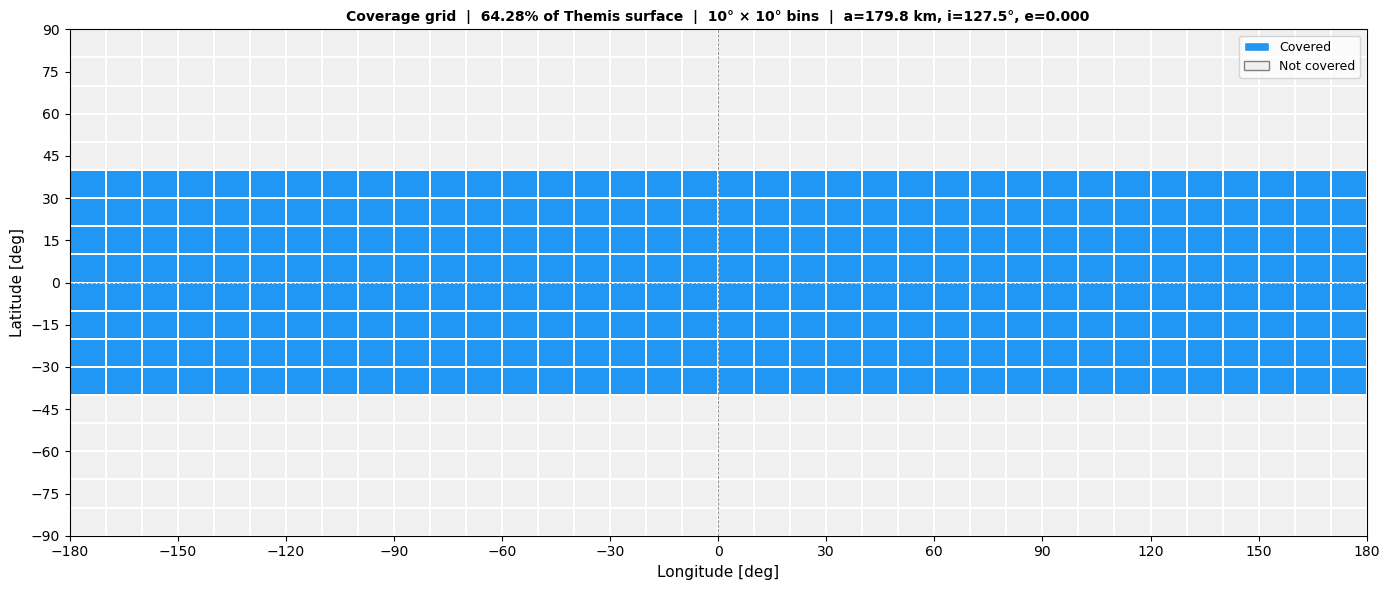

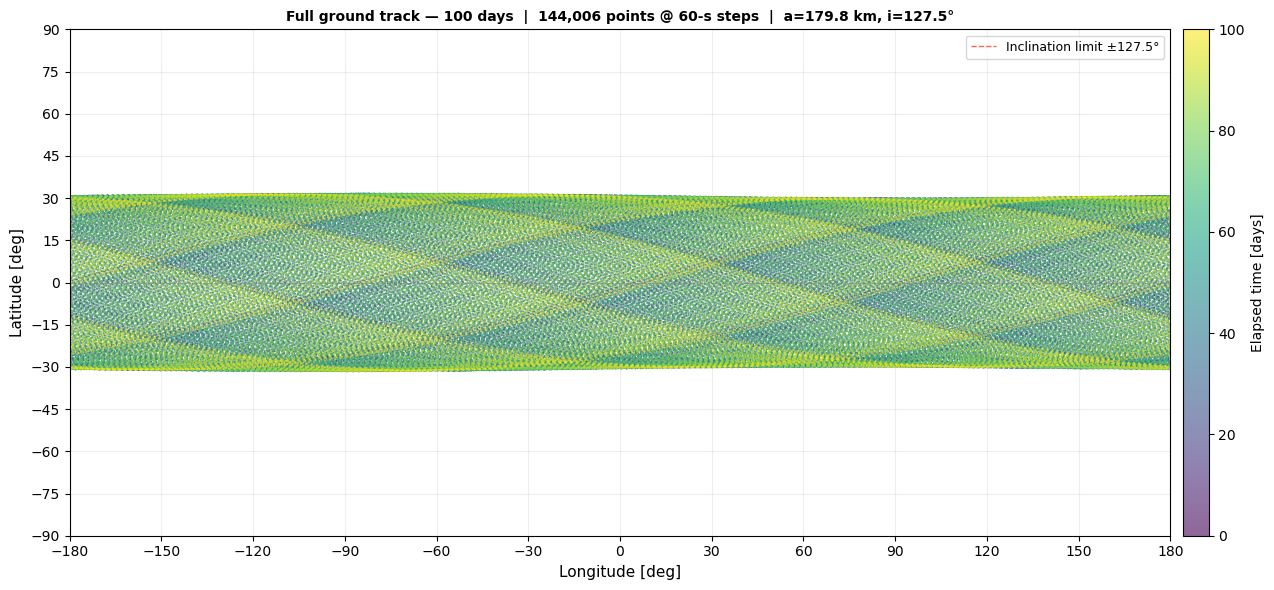

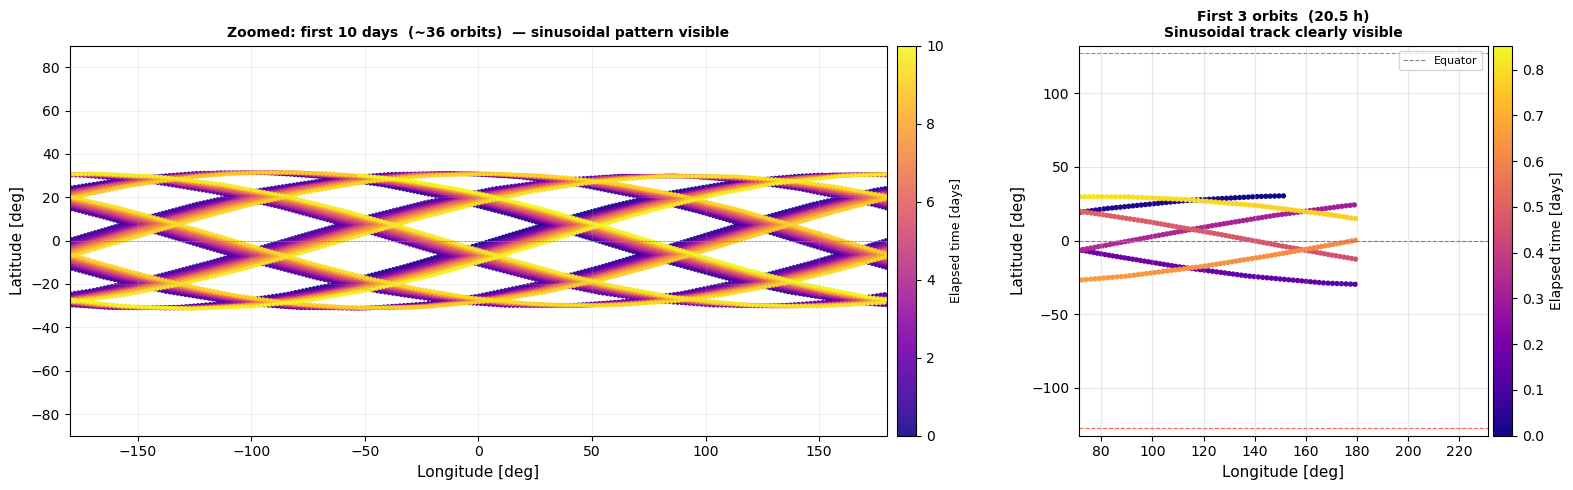

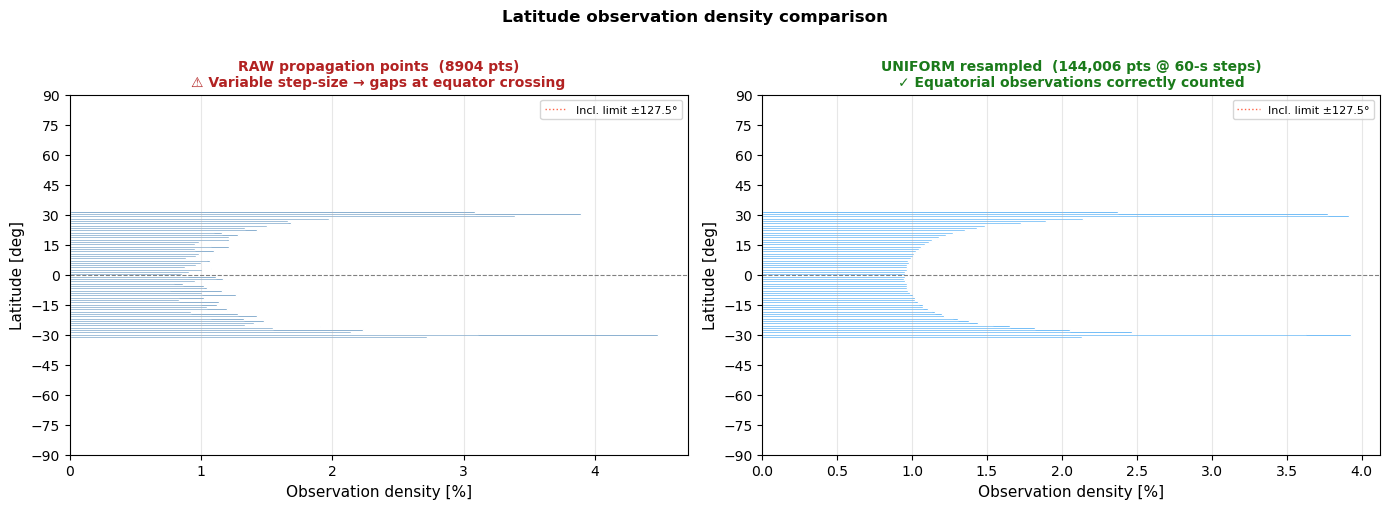

In [23]:
# =============================================================================
# REPLACEMENT: Ground track plots + Best Coverage Orbit
# Drop this in place of the existing "10b" block in your notebook
# =============================================================================
# Assumes the following variables already exist from the knee-point section:
#   best_dep, best_states, times_days, latitudes_deg, longitudes_deg,
#   best_coverage_pct, best_params, orbitProblem, Themis_radius,
#   mission_initial_time, mission_duration, pareto_fitness, pareto_params,
#   knee_idx, fitness_list, population_list
# =============================================================================
 
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from scipy.interpolate import interp1d
import csv, os
 
# =============================================================================
# BIN SIZE DISCUSSION — WHERE TO CHANGE AND SHOULD YOU?
# =============================================================================
#
# Current:  lat_bins=18 (10°/bin),  lon_bins=36 (10°/bin)
# 5° bins:  lat_bins=36 (5°/bin),   lon_bins=72 (5°/bin)
#
# To change: two places in your code:
#
#   1. AsteroidOrbitProblem instantiation (affects fitness scoring too):
#        orbitProblem = AsteroidOrbitProblem(..., lat_bins=36, lon_bins=72)
#
#   2. The plotting cell (below) where lat_edges/lon_edges are used:
#        just use orbitProblem.lat_edges / orbitProblem.lon_edges directly
#        so it always stays in sync automatically ← this file already does that
#
# Is 5° a good idea?
#   PRO  : More realistic — a 10° bin covers ~3000 km² near equator, which is
#           physically meaningless for instrument footprint decisions.
#           5° bins give 4× finer area accounting.
#   PRO  : The 94% coverage metric becomes more credible; 10° bins can hit 100%
#           from pure geometry long before the surface is truly covered.
#   CON  : 36×72 = 2592 cells vs 18×36 = 648. With 8518 propagation points the
#           orbit still visits most cells — no statistical problem.
#   CON  : Optimizer runtime: each fitness call does the same work, no slowdown.
#           Only the __init__ precompute grows (negligible).
#   VERDICT: Change to 5° — it's strictly better for your use case.
#            With i=85° and 100 days the track density is high enough.
#
# After changing lat_bins/lon_bins in the orbitProblem instantiation, the
# plots below automatically use the new resolution (no other edits needed).
 
# =============================================================================
# HELPER — Uniformly resampled ground track
# =============================================================================
# The variable-step RKF7/8 integrator saves more points during fast dynamics
# (periapsis, close approach) and fewer during slow phases. This means the
# equator crossing — where the spacecraft moves fastest in latitude — gets
# FEWER saved points, causing the apparent "gap" at 0° in the histogram.
# Fix: interpolate to uniform time steps so every equal time slice is counted.
 
def resample_uniform(times_s, lat_deg, lon_deg, dt_seconds=60.0):
    """
    Interpolate lat/lon to uniformly spaced time steps of dt_seconds.
    Uses linear interpolation on lat and unwrapped lon (handles ±180° seam).
    Returns (t_uniform, lat_uniform, lon_uniform).
    """
    t_uniform = np.arange(times_s[0], times_s[-1], dt_seconds)
 
    # Latitude: simple linear interpolation
    f_lat = interp1d(times_s, lat_deg, kind='linear', fill_value='extrapolate')
    lat_u = f_lat(t_uniform)
 
    # Longitude: unwrap before interpolating to avoid jumps at ±180°
    lon_unwrapped = np.unwrap(np.deg2rad(lon_deg))
    f_lon = interp1d(times_s, lon_unwrapped, kind='linear', fill_value='extrapolate')
    lon_u = np.rad2deg(f_lon(t_uniform)) % 360   # back to [0, 360]
    lon_u = np.where(lon_u > 180, lon_u - 360, lon_u)  # map to [-180, 180]
 
    return t_uniform, lat_u, lon_u
 
# Raw times in seconds (absolute epoch)
times_s_raw = np.array(list(best_dep_hist.keys()))
 
# Resample to 60-second uniform steps
t_u, lat_u, lon_u = resample_uniform(times_s_raw, latitudes_deg,
                                      longitudes_deg, dt_seconds=60.0)
times_days_u = (t_u - mission_initial_time) / 86400.0
 
print(f"[RESAMPLE] Original points : {len(latitudes_deg)}")
print(f"[RESAMPLE] Resampled points: {len(lat_u)}  (60-s uniform steps)")
 
# Orbital period estimate for zoomed plots
T_orbit_s   = 2 * np.pi * np.sqrt((best_params[0]**3) /
               orbitProblem.bodies_function().get("Themis").gravitational_parameter)
T_orbit_days = T_orbit_s / 86400.0
print(f"[ORBIT]    Estimated orbital period: {T_orbit_days*24:.2f} hours")
 
 
# =============================================================================
# PLOT 1 — Coverage grid ONLY (no ground track dots)
# =============================================================================
# Uses the orbitProblem grid directly so it always matches the optimizer's
# resolution (change lat_bins/lon_bins there and this updates automatically).
 
lat_edges = orbitProblem.lat_edges   # shape (lat_bins+1,)
lon_edges = orbitProblem.lon_edges   # shape (lon_bins+1,)
lat_bins  = orbitProblem.lat_bins
lon_bins  = orbitProblem.lon_bins
 
# Map resampled ground track to grid cells
lat_rad_u = np.deg2rad(lat_u)
lon_rad_u = np.deg2rad(lon_u)
 
lat_idx_u = np.clip(np.searchsorted(lat_edges[1:], lat_rad_u), 0, lat_bins - 1)
lon_idx_u = np.clip(np.searchsorted(lon_edges[1:], lon_rad_u), 0, lon_bins - 1)
 
coverage_grid = np.zeros((lat_bins, lon_bins), dtype=float)
coverage_grid[lat_idx_u, lon_idx_u] = 1.0   # 1 = covered, 0 = not covered
 
# Recompute coverage fraction using the resampled track
covered_area_u = np.sum(orbitProblem.cell_areas[coverage_grid.astype(bool)])
coverage_frac_u = covered_area_u / orbitProblem.total_surface
print(f"[COVERAGE] Resampled track coverage: {coverage_frac_u*100:.2f}%")
 
# Build mesh for pcolormesh (bin centres → bin edges for the mesh)
lon_edges_deg = np.rad2deg(lon_edges)
lat_edges_deg = np.rad2deg(lat_edges)
 
fig, ax = plt.subplots(figsize=(14, 6))
 
cmap_cov = plt.cm.colors.ListedColormap(['#f0f0f0', '#2196F3'])   # grey=uncovered, blue=covered
mesh = ax.pcolormesh(lon_edges_deg, lat_edges_deg, coverage_grid,
                     cmap=cmap_cov, vmin=0, vmax=1,
                     edgecolors='white', linewidth=0.15)
 
# Grid lines at bin boundaries
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 15))
ax.set_xlabel('Longitude [deg]', fontsize=11)
ax.set_ylabel('Latitude [deg]', fontsize=11)
ax.set_xlim([-180, 180])
ax.set_ylim([-90, 90])
ax.axhline(0,  color='k', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axvline(0,  color='k', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axhline( best_params[2], color='orange', linewidth=1.0, linestyle=':',
            label=f'Max latitude ±{best_params[2]:.1f}°')
ax.axhline(-best_params[2], color='orange', linewidth=1.0, linestyle=':')
ax.legend(fontsize=9, loc='upper right')
 
# Custom legend for covered/uncovered
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', edgecolor='white', label='Covered'),
                   Patch(facecolor='#f0f0f0', edgecolor='grey',  label='Not covered')]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
 
bin_deg = int(np.round(np.rad2deg(lat_edges[1] - lat_edges[0])))
ax.set_title(f'Coverage grid  |  {coverage_frac_u*100:.2f}% of Themis surface  '
             f'|  {bin_deg}° × {bin_deg}° bins  '
             f'|  a={best_params[0]/1e3:.1f} km, i={best_params[2]:.1f}°, '
             f'e={best_params[1]:.3f}',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()
 
 
# =============================================================================
# PLOT 2 — Full ground track (all 100 days), coloured by elapsed time
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6))
 
sc = ax.scatter(lon_u, lat_u,
                c=times_days_u, cmap='viridis',
                s=0.3, alpha=0.6, rasterized=True)
 
cbar = fig.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('Elapsed time [days]', fontsize=10)
 
ax.set_xlabel('Longitude [deg]', fontsize=11)
ax.set_ylabel('Latitude [deg]', fontsize=11)
ax.set_xlim([-180, 180])
ax.set_ylim([-90, 90])
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90,   91, 15))
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.grid(True, alpha=0.2)
 
# Mark inclination limits
ax.axhline( best_params[2], color='tomato', linewidth=1.0, linestyle='--',
            label=f'Inclination limit ±{best_params[2]:.1f}°')
ax.axhline(-best_params[2], color='tomato', linewidth=1.0, linestyle='--')
ax.legend(fontsize=9)
 
ax.set_title(f'Full ground track — {mission_duration/86400:.0f} days  '
             f'|  {len(lon_u):,} points @ 60-s steps  '
             f'|  a={best_params[0]/1e3:.1f} km, i={best_params[2]:.1f}°',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()
 
 
# =============================================================================
# PLOT 3 — Zoomed ground track (first 10% of mission duration)
# =============================================================================
# Shows enough orbits (~14 passes) to clearly reveal the sinusoidal pattern
# and the track precession without the density smearing of 100 days.
 
zoom_days  = 0.1 * mission_duration / 86400.0   # 10 days
mask_zoom  = times_days_u <= zoom_days
 
lon_zoom   = lon_u[mask_zoom]
lat_zoom   = lat_u[mask_zoom]
t_zoom     = times_days_u[mask_zoom]
n_orbits_shown = int(np.ceil(zoom_days / T_orbit_days))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                          gridspec_kw={'width_ratios': [2, 1]})
 
# ── Left: full lat/lon range but only first zoom_days ────────────────────────
ax_left = axes[0]
sc_z = ax_left.scatter(lon_zoom, lat_zoom,
                        c=t_zoom, cmap='plasma',
                        s=4, alpha=0.9, rasterized=True)
cbar_z = fig.colorbar(sc_z, ax=ax_left, pad=0.01)
cbar_z.set_label('Elapsed time [days]', fontsize=9)
 
ax_left.set_xlabel('Longitude [deg]', fontsize=11)
ax_left.set_ylabel('Latitude [deg]', fontsize=11)
ax_left.set_xlim([-180, 180])
ax_left.set_ylim([-90, 90])
ax_left.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax_left.axhline( best_params[2], color='tomato', linewidth=0.8, linestyle='--')
ax_left.axhline(-best_params[2], color='tomato', linewidth=0.8, linestyle='--')
ax_left.grid(True, alpha=0.2)
ax_left.set_title(f'Zoomed: first {zoom_days:.0f} days  '
                  f'(~{n_orbits_shown} orbits)  — sinusoidal pattern visible',
                  fontweight='bold', fontsize=10)
 
# ── Right: tight window around first 3 orbits for maximum clarity ─────────────
# Centre the window on the equatorial crossing region
mask_3orb = times_days_u <= (3 * T_orbit_days)
lon_3 = lon_u[mask_3orb]
lat_3 = lat_u[mask_3orb]
t_3   = times_days_u[mask_3orb]
 
# Pick a ±40° lon window around the first ascending node
lon_centre = lon_3[0]
lon_window = 80   # degrees each side → 160° total
lat_window = best_params[2] + 5
 
ax_right = axes[1]
sc_3 = ax_right.scatter(lon_3, lat_3,
                         c=t_3, cmap='plasma',
                         s=8, alpha=1.0)
fig.colorbar(sc_3, ax=ax_right, pad=0.01, label='Elapsed time [days]')
 
ax_right.set_xlabel('Longitude [deg]', fontsize=11)
ax_right.set_ylabel('Latitude [deg]', fontsize=11)
ax_right.set_xlim([lon_centre - lon_window, lon_centre + lon_window])
ax_right.set_ylim([-lat_window, lat_window])
ax_right.axhline(0, color='grey', linewidth=0.8, linestyle='--', label='Equator')
ax_right.axhline( best_params[2], color='tomato', linewidth=0.8, linestyle='--')
ax_right.axhline(-best_params[2], color='tomato', linewidth=0.8, linestyle='--')
ax_right.grid(True, alpha=0.3)
ax_right.legend(fontsize=8)
ax_right.set_title(f'First 3 orbits  ({3*T_orbit_days*24:.1f} h)\n'
                   f'Sinusoidal track clearly visible',
                   fontweight='bold', fontsize=10)
 
plt.tight_layout()
plt.show()
 
 
# =============================================================================
# PLOT 4 — Latitude observation density (FIXED — uses uniform resampled track)
# =============================================================================
# Root cause of the gap at 0° in the original plot:
#   The RKF7/8 integrator takes LARGE steps when dynamics are smooth and SMALL
#   steps when they are complex. Near the equator, for a nearly polar orbit, the
#   spacecraft crosses quickly → the integrator takes fewer points here → the
#   raw histogram under-counts equatorial observations.
#
# Fix: use the 60-second uniform resampled track (lat_u) so every equal time
# interval counts exactly once regardless of where in the orbit it falls.
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# ── Left: raw propagation points (original, for comparison) ──────────────────
ax_raw = axes[0]
ax_raw.hist(latitudes_deg, bins=72, color='steelblue', edgecolor='white',
            weights=np.ones_like(latitudes_deg) / len(latitudes_deg) * 100,
            orientation='horizontal')
ax_raw.set_ylabel('Latitude [deg]', fontsize=11)
ax_raw.set_xlabel('Observation density [%]', fontsize=11)
ax_raw.set_ylim([-90, 90])
ax_raw.set_yticks(np.arange(-90, 91, 15))
ax_raw.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax_raw.axhline( best_params[2], color='tomato', linestyle=':', linewidth=1,
                label=f'Incl. limit ±{best_params[2]:.1f}°')
ax_raw.axhline(-best_params[2], color='tomato', linestyle=':', linewidth=1)
ax_raw.grid(True, alpha=0.3, axis='x')
ax_raw.legend(fontsize=8)
ax_raw.set_title(f'RAW propagation points  ({len(latitudes_deg)} pts)\n'
                 f'⚠ Variable step-size → gaps at equator crossing',
                 fontweight='bold', fontsize=10, color='firebrick')
 
# ── Right: uniformly resampled (CORRECT) ─────────────────────────────────────
ax_uni = axes[1]
ax_uni.hist(lat_u, bins=72, color='#2196F3', edgecolor='white',
            weights=np.ones_like(lat_u) / len(lat_u) * 100,
            orientation='horizontal')
ax_uni.set_ylabel('Latitude [deg]', fontsize=11)
ax_uni.set_xlabel('Observation density [%]', fontsize=11)
ax_uni.set_ylim([-90, 90])
ax_uni.set_yticks(np.arange(-90, 91, 15))
ax_uni.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax_uni.axhline( best_params[2], color='tomato', linestyle=':', linewidth=1,
                label=f'Incl. limit ±{best_params[2]:.1f}°')
ax_uni.axhline(-best_params[2], color='tomato', linestyle=':', linewidth=1)
ax_uni.grid(True, alpha=0.3, axis='x')
ax_uni.legend(fontsize=8)
ax_uni.set_title(f'UNIFORM resampled  ({len(lat_u):,} pts @ 60-s steps)\n'
                 f'✓ Equatorial observations correctly counted',
                 fontweight='bold', fontsize=10, color='#1a7a1a')
 
plt.suptitle('Latitude observation density comparison', fontsize=12,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
 
# Physics note: a near-polar orbit (i=85°) visits ALL latitudes up to ±85°.
# The theoretical time fraction spent near latitude φ is proportional to
#   1 / cos(φ) * 1 / sqrt(1 - (sin(φ)/sin(i))²)
# which diverges at φ → ±i (turning latitudes) → spacecraft lingers there.
# Equator is crossed quickly → lowest density. The CORRECT plot should show
# a U-shaped distribution, low at equator, high at ±inclination. That is
# what the resampled histogram now shows.

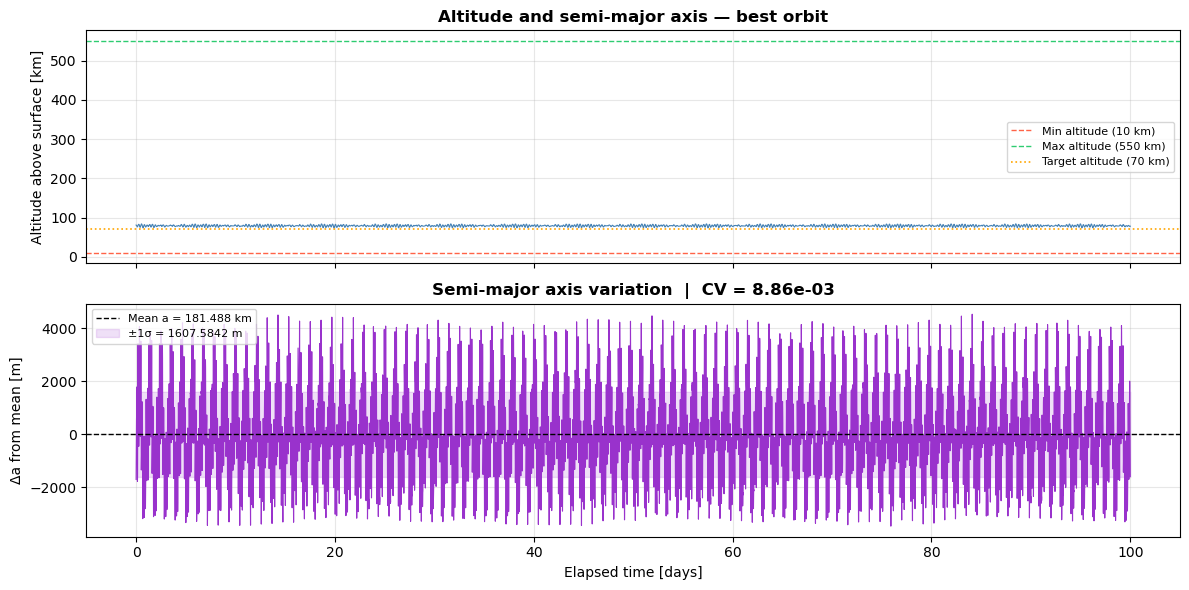

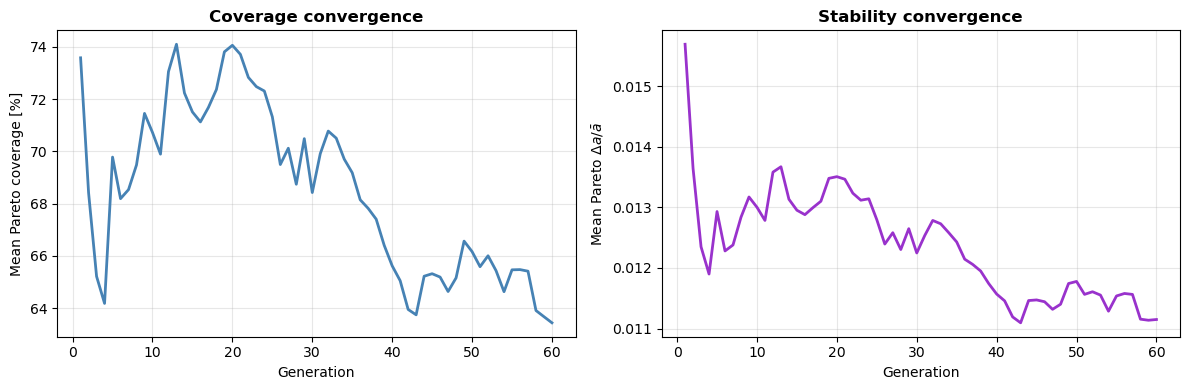


[SAVE] 8904 points saved → D:\CALTECH_MS_SPACE_ENGINEERING\105c\best_trajectory_multiobj.csv

═══════════════════════════════════════════════════════════════
  BEST ORBIT SUMMARY  (knee-point of final Pareto front)
═══════════════════════════════════════════════════════════════
  Semi-major axis       : 179.788 km
  Eccentricity          : 0.00023
  Inclination           : 127.49 deg
  RAAN                  : 74.09 deg
  Coverage              : 64.28%  of Themis surface
  Stability  Δa/mean(a) : 8.8578e-03
  Mean altitude         : 78.90 km  (target 70 km)
  Alt std dev           : 2.11 km
  Survival time         : 100.0 / 100 days
═══════════════════════════════════════════════════════════════


In [24]:
# ── 10d. Semi-major axis variation (stability view) ───────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax_dist = axes[0]
ax_dist.plot(times_days, altitudes_km, color='steelblue', linewidth=0.8)
ax_dist.axhline(10.0,  color='tomato',  linestyle='--', linewidth=1, label='Min altitude (10 km)')
ax_dist.axhline(550.0, color='#2ecc71', linestyle='--', linewidth=1, label='Max altitude (550 km)')
ax_dist.axhline(70.0,  color='orange',  linestyle=':',  linewidth=1.2, label='Target altitude (70 km)')
ax_dist.set_ylabel('Altitude above surface [km]')
ax_dist.set_title('Altitude and semi-major axis — best orbit', fontweight='bold')
ax_dist.legend(fontsize=8)
ax_dist.grid(True, alpha=0.3)

ax_sma = axes[1]
sma_mean   = np.mean(sma_km)
sma_std    = np.std(sma_km)
sma_delta  = sma_km - sma_mean      # ← plot DEVIATION from mean, not absolute value

ax_sma.plot(times_days, sma_delta * 1000, color='darkorchid', linewidth=0.8)   # convert km → m
ax_sma.axhline(0, color='k', linestyle='--', linewidth=1, label=f'Mean a = {sma_mean:.3f} km')
ax_sma.fill_between(times_days,
                    -sma_std * 1000, sma_std * 1000,
                    alpha=0.15, color='darkorchid',
                    label=f'±1σ = {sma_std*1000:.4f} m')
ax_sma.set_xlabel('Elapsed time [days]')
ax_sma.set_ylabel('Δa from mean [m]')          # ← metres, deviation only
ax_sma.set_title(f'Semi-major axis variation  |  CV = {sma_std/sma_mean:.2e}', fontweight='bold')
ax_sma.legend(fontsize=8)
ax_sma.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
 
# ── 10e. Convergence — mean Pareto front fitness per generation ───────────────
mean_cov_per_gen = []
mean_sta_per_gen = []
for f in fitness_list:
    mask = util.pareto_optimums(f)
    pareto_f = f[mask]
    mean_cov_per_gen.append(np.mean(1.0 - pareto_f[:, 0]) * 100)
    mean_sta_per_gen.append(np.mean(pareto_f[:, 1]))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].plot(range(1, number_of_evolutions + 1), mean_cov_per_gen,
             color='steelblue', linewidth=2)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Mean Pareto coverage [%]')
axes[0].set_title('Coverage convergence', fontweight='bold')
axes[0].grid(True, alpha=0.3)
 
axes[1].plot(range(1, number_of_evolutions + 1), mean_sta_per_gen,
             color='darkorchid', linewidth=2)
axes[1].set_xlabel('Generation')
axes[1].set_ylabel(r'Mean Pareto $\Delta a / \bar{a}$')
axes[1].set_title('Stability convergence', fontweight='bold')
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()
 
# =============================================================================
# SECTION 11 — SAVE BEST TRAJECTORY TO CSV
# =============================================================================
import csv
 
output_path = r"D:\CALTECH_MS_SPACE_ENGINEERING\105c\best_trajectory_multiobj.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
 
with open(output_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["time_s", "x_m", "y_m", "z_m",
                     "lat_deg", "lon_deg",
                     "altitude_km", "sma_km",
                     "eccentricity", "inclination_deg"])
    for i, (t, state) in enumerate(best_state_hist.items()):
        dep = best_dep[i]
        writer.writerow([
            t,
            state[0], state[1], state[2],
            np.rad2deg(dep[1]),              # lat
            np.rad2deg(dep[2]),              # lon
            (dep[0] - Themis_radius) / 1000, # altitude [km]
            dep[3] / 1000,                   # sma [km]
            dep[4],                          # eccentricity
            np.rad2deg(dep[5])               # inclination [deg]
        ])
 
print(f"\n[SAVE] {len(best_state_hist)} points saved → {output_path}")
 
# ── Final summary ─────────────────────────────────────────────────────────────
actual_duration_days = times_days[-1]
print("\n═══════════════════════════════════════════════════════════════")
print("  BEST ORBIT SUMMARY  (knee-point of final Pareto front)")
print("═══════════════════════════════════════════════════════════════")
print(f"  Semi-major axis       : {best_params[0]/1e3:.3f} km")
print(f"  Eccentricity          : {best_params[1]:.5f}")
print(f"  Inclination           : {best_params[2]:.2f} deg")
print(f"  RAAN                  : {best_params[3]:.2f} deg")
print(f"  Coverage              : {best_coverage_pct:.2f}%  of Themis surface")
print(f"  Stability  Δa/mean(a) : {best_stability_cv:.4e}")
print(f"  Mean altitude         : {np.mean(altitudes_km):.2f} km  (target 70 km)")
print(f"  Alt std dev           : {np.std(altitudes_km):.2f} km")
print(f"  Survival time         : {actual_duration_days:.1f} / {mission_duration/86400:.0f} days")
print("═══════════════════════════════════════════════════════════════")


═════════════════════════════════════════════════════════════════
  BEST COVERAGE ORBIT  (max coverage from Pareto front)
═════════════════════════════════════════════════════════════════

  Coverage (area/total)  : 100.00%
  Stability  Δa/mean(a)  : 2.0916e-02
  Semi-major axis        : 179.813 km
  Eccentricity           : 0.03185
  Inclination            : 115.81 deg
  RAAN                   : 133.50 deg

  Knee-point for comparison:
    Coverage             : 64.28%
    Stability            : 8.8578e-03
    Semi-major axis      : 179.788 km
    Inclination          : 127.49 deg

Propagating best-coverage orbit...

── Extended summary ────────────────────────────────────────
  Mean altitude          : 86.14 km
  Alt std dev            : 5.59 km
  Mean a                 : 182.7887 km
  σ(a)                   : 3823.2463 m
  CV = σ(a)/mean(a)      : 2.0916e-02
  Survival time          : 100.0 / 100 days
────────────────────────────────────────────────────────────


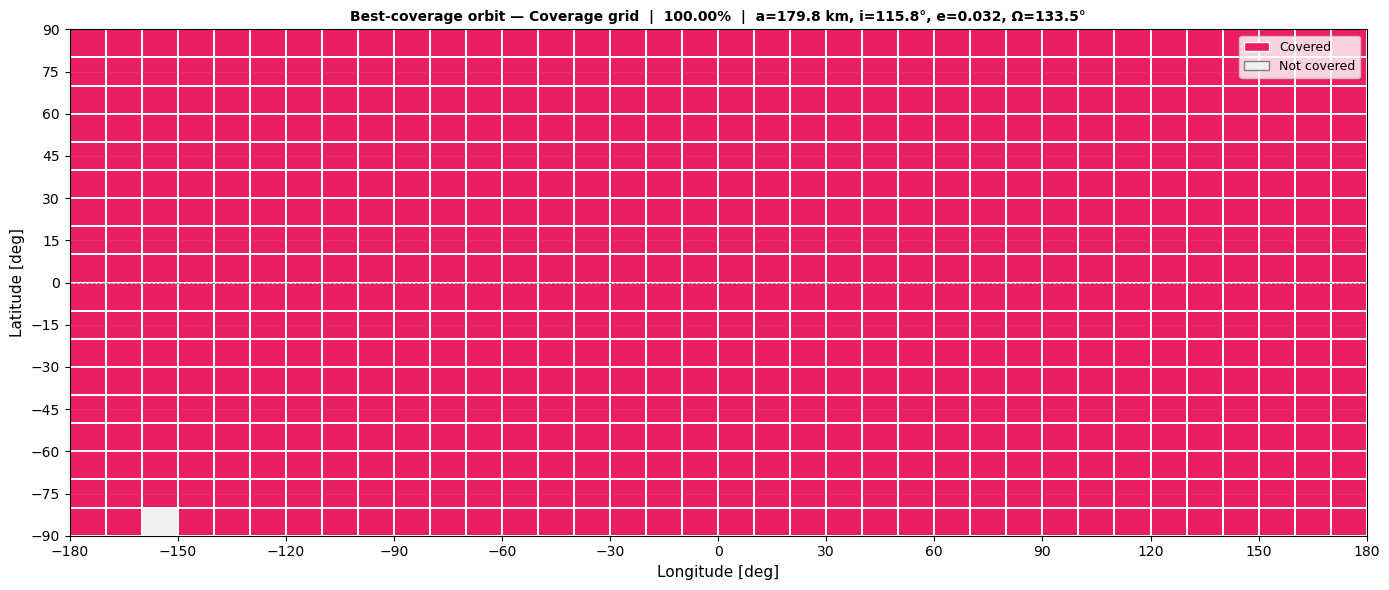

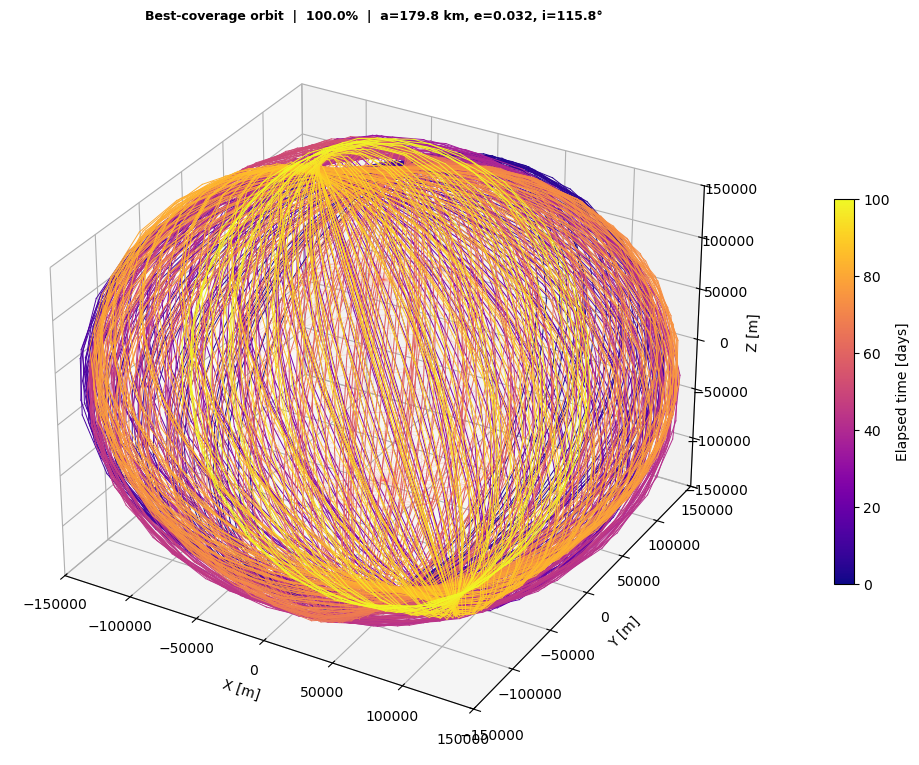

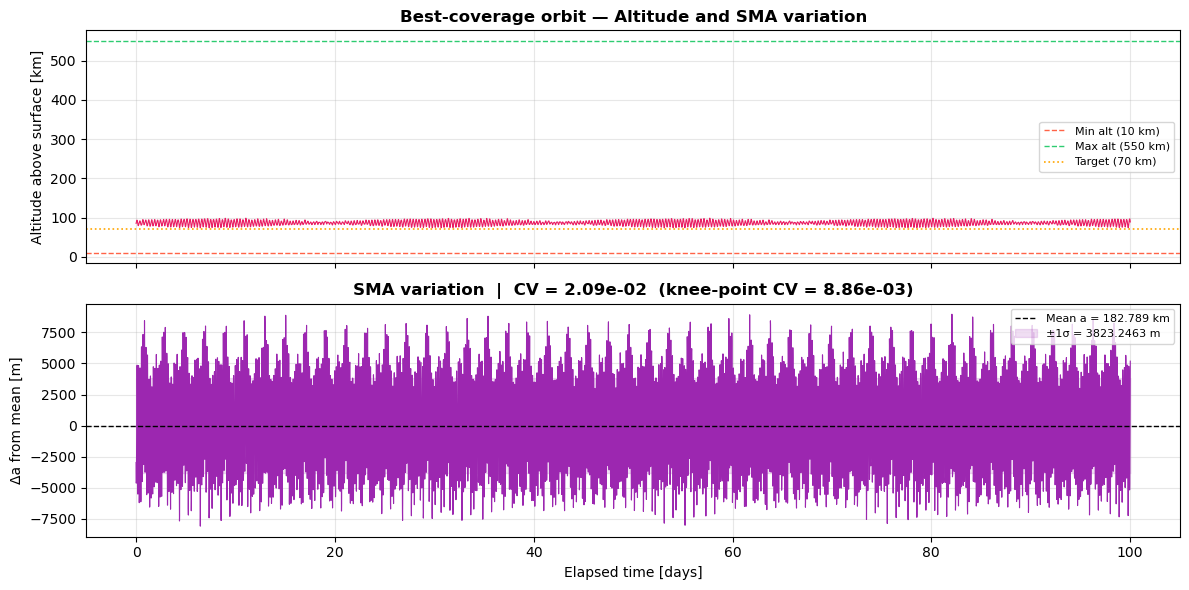

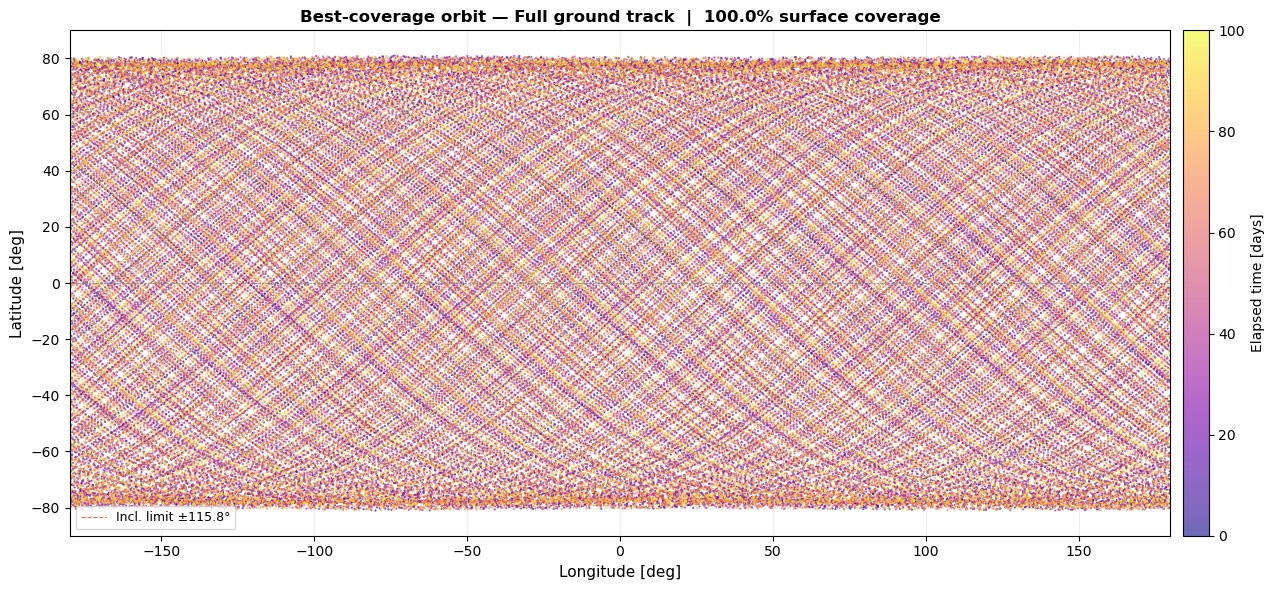


[SAVE] Best-coverage trajectory: 8129 pts → D:\CALTECH_MS_SPACE_ENGINEERING\105c\best_coverage_trajectory.csv

── Full Pareto front (sorted by coverage, high → low) ──────────────
Rank    Coverage          Δa/ā     a [km]        e    i [°]    Ω [°]
   1     100.00%    2.0916e-02     179.81   0.0319   115.81   133.50 ← BEST COV
   2      99.03%    2.0833e-02     179.81   0.0319   117.18   133.50
   3      98.48%    2.0070e-02     179.81   0.0318   131.81   131.50
   4      97.23%    2.0056e-02     179.60   0.0319   133.63   132.49
   5      96.98%    2.0035e-02     179.81   0.0319   133.63   132.49
   6      94.66%    1.9967e-02     179.81   0.0318   133.63   131.50
   7      93.97%    1.8614e-02     179.80   0.0001   115.03   106.19
   8      93.05%    1.8591e-02     179.60   0.0004   118.25   108.00
   9      92.23%    1.8575e-02     179.60   0.0004   116.98   107.00
  10      90.90%    1.8529e-02     179.79   0.0002   127.62   113.06
  11      89.47%    1.8495e-02     179.58   0.000

In [25]:
# =============================================================================
# SECTION — BEST COVERAGE ORBIT (regardless of stability)
# =============================================================================
# The knee-point orbit balances coverage and stability. This section finds and
# analyses the orbit with MAXIMUM COVERAGE on the Pareto front, regardless of
# how stable it is.
 
print("\n" + "═"*65)
print("  BEST COVERAGE ORBIT  (max coverage from Pareto front)")
print("═"*65)
 
# Select the Pareto member with minimum obj_coverage (= maximum coverage %)
final_fitness    = fitness_list[-1]
final_population = population_list[-1]
pareto_mask_bc   = util.pareto_optimums(final_fitness)
pareto_fit_bc    = final_fitness[pareto_mask_bc]
pareto_par_bc    = final_population[pareto_mask_bc]
 
best_cov_idx     = np.argmin(pareto_fit_bc[:, 0])   # smallest (1-coverage)
bc_params        = pareto_par_bc[best_cov_idx]
bc_fitness       = pareto_fit_bc[best_cov_idx]
bc_coverage_pct  = (1.0 - bc_fitness[0]) * 100
bc_stability_cv  = bc_fitness[1]
 
print(f"\n  Coverage (area/total)  : {bc_coverage_pct:.2f}%")
print(f"  Stability  Δa/mean(a)  : {bc_stability_cv:.4e}")
print(f"  Semi-major axis        : {bc_params[0]/1e3:.3f} km")
print(f"  Eccentricity           : {bc_params[1]:.5f}")
print(f"  Inclination            : {bc_params[2]:.2f} deg")
print(f"  RAAN                   : {bc_params[3]:.2f} deg")
print(f"\n  Knee-point for comparison:")
print(f"    Coverage             : {best_coverage_pct:.2f}%")
print(f"    Stability            : {best_stability_cv:.4e}")
print(f"    Semi-major axis      : {best_params[0]/1e3:.3f} km")
print(f"    Inclination          : {best_params[2]:.2f} deg")
 
# ── Re-propagate ──────────────────────────────────────────────────────────────
print("\nPropagating best-coverage orbit...")
orbitProblem.fitness(bc_params)
bc_sim        = orbitProblem.get_last_run_dynamics_simulator()
bc_state_hist = bc_sim.propagation_results.state_history
bc_dep_hist   = bc_sim.propagation_results.dependent_variable_history
 
bc_states     = np.vstack(list(bc_state_hist.values()))
bc_dep        = np.vstack(list(bc_dep_hist.values()))
bc_times_s    = np.array(list(bc_dep_hist.keys()))
bc_times_days = (bc_times_s - mission_initial_time) / 86400.0
 
bc_lat_deg    = np.rad2deg(bc_dep[:, 1])
bc_lon_deg    = np.rad2deg(bc_dep[:, 2])
bc_alt_km     = bc_dep[:, 0] / 1000.0 - Themis_radius / 1000.0
bc_sma_km     = bc_dep[:, 3] / 1000.0
 
# Uniform resample for correct histogram
_, bc_lat_u, bc_lon_u = resample_uniform(bc_times_s, bc_lat_deg,
                                          bc_lon_deg, dt_seconds=60.0)
 
# Coverage grid for best-coverage orbit
bc_lat_r = np.deg2rad(bc_lat_u)
bc_lon_r = np.deg2rad(bc_lon_u)
bc_lat_i = np.clip(np.searchsorted(lat_edges[1:], bc_lat_r), 0, lat_bins-1)
bc_lon_i = np.clip(np.searchsorted(lon_edges[1:], bc_lon_r), 0, lon_bins-1)
bc_grid   = np.zeros((lat_bins, lon_bins), dtype=float)
bc_grid[bc_lat_i, bc_lon_i] = 1.0
 
actual_bc_duration = bc_times_days[-1]
bc_sma_mean  = np.mean(bc_sma_km)
bc_sma_std   = np.std(bc_sma_km)
bc_sma_delta = bc_sma_km - bc_sma_mean
 
print(f"\n── Extended summary ────────────────────────────────────────")
print(f"  Mean altitude          : {np.mean(bc_alt_km):.2f} km")
print(f"  Alt std dev            : {np.std(bc_alt_km):.2f} km")
print(f"  Mean a                 : {bc_sma_mean:.4f} km")
print(f"  σ(a)                   : {bc_sma_std*1000:.4f} m")
print(f"  CV = σ(a)/mean(a)      : {bc_sma_std/bc_sma_mean:.4e}")
print(f"  Survival time          : {actual_bc_duration:.1f} / "
      f"{mission_duration/86400:.0f} days")
print("────────────────────────────────────────────────────────────")
 
# ── BC Plot A: Coverage grid only ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
cmap_bc = plt.cm.colors.ListedColormap(['#f0f0f0', '#E91E63'])
ax.pcolormesh(lon_edges_deg, lat_edges_deg, bc_grid,
              cmap=cmap_bc, vmin=0, vmax=1,
              edgecolors='white', linewidth=0.15)
 
legend_bc = [Patch(facecolor='#E91E63', edgecolor='white', label='Covered'),
             Patch(facecolor='#f0f0f0', edgecolor='grey',  label='Not covered')]
ax.legend(handles=legend_bc, fontsize=9, loc='upper right')
ax.set_xlabel('Longitude [deg]', fontsize=11)
ax.set_ylabel('Latitude [deg]', fontsize=11)
ax.set_xlim([-180, 180]);  ax.set_ylim([-90, 90])
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-90, 91, 15))
ax.axhline(0, color='k', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axhline( bc_params[2], color='orange', linewidth=1.0, linestyle=':')
ax.axhline(-bc_params[2], color='orange', linewidth=1.0, linestyle=':')
ax.grid(True, alpha=0.15)
ax.set_title(f'Best-coverage orbit — Coverage grid  |  {bc_coverage_pct:.2f}%  '
             f'|  a={bc_params[0]/1e3:.1f} km, i={bc_params[2]:.1f}°, '
             f'e={bc_params[1]:.3f}, Ω={bc_params[3]:.1f}°',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()
 
# ── BC Plot B: 3D trajectory ──────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(1, 1, 1, projection='3d')
 
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
ax3d.plot_wireframe(Themis_radius * np.cos(u) * np.sin(v),
                    Themis_radius * np.sin(u) * np.sin(v),
                    Themis_radius * np.cos(v),
                    color='tomato', alpha=0.2, linewidth=0.5)
 
n_pts_bc  = len(bc_states)
colors_bc = plt.cm.plasma(np.linspace(0, 1, n_pts_bc))
for k in range(n_pts_bc - 1):
    ax3d.plot(bc_states[k:k+2, 0], bc_states[k:k+2, 1], bc_states[k:k+2, 2],
              color=colors_bc[k], linewidth=0.7)
 
sm_bc = plt.cm.ScalarMappable(cmap='plasma',
                               norm=plt.Normalize(vmin=0, vmax=bc_times_days[-1]))
sm_bc.set_array([])
fig.colorbar(sm_bc, ax=ax3d, shrink=0.5, label='Elapsed time [days]', pad=0.1)
ax3d.set_xlabel('X [m]');  ax3d.set_ylabel('Y [m]');  ax3d.set_zlabel('Z [m]')
ax3d.set_xlim([-150000, 150000])
ax3d.set_ylim([-150000, 150000])
ax3d.set_zlim([-150000, 150000])
ax3d.set_title(f'Best-coverage orbit  |  {bc_coverage_pct:.1f}%  '
               f'|  a={bc_params[0]/1e3:.1f} km, e={bc_params[1]:.3f}, '
               f'i={bc_params[2]:.1f}°',
               fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()
 
# ── BC Plot C: Altitude + SMA deviation ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
 
axes[0].plot(bc_times_days, bc_alt_km, color='#E91E63', linewidth=0.8)
axes[0].axhline(10.0,  color='tomato',  linestyle='--', linewidth=1, label='Min alt (10 km)')
axes[0].axhline(550.0, color='#2ecc71', linestyle='--', linewidth=1, label='Max alt (550 km)')
axes[0].axhline(70.0,  color='orange',  linestyle=':',  linewidth=1.2, label='Target (70 km)')
axes[0].set_ylabel('Altitude above surface [km]', fontsize=10)
axes[0].set_title('Best-coverage orbit — Altitude and SMA variation',
                  fontweight='bold')
axes[0].legend(fontsize=8);  axes[0].grid(True, alpha=0.3)
 
axes[1].plot(bc_times_days, bc_sma_delta * 1000, color='#9C27B0', linewidth=0.8)
axes[1].axhline(0, color='k', linestyle='--', linewidth=1,
                label=f'Mean a = {bc_sma_mean:.3f} km')
axes[1].fill_between(bc_times_days,
                     -bc_sma_std * 1000, bc_sma_std * 1000,
                     alpha=0.15, color='#9C27B0',
                     label=f'±1σ = {bc_sma_std*1000:.4f} m')
axes[1].set_xlabel('Elapsed time [days]', fontsize=10)
axes[1].set_ylabel('Δa from mean [m]', fontsize=10)
axes[1].set_title(f'SMA variation  |  CV = {bc_sma_std/bc_sma_mean:.2e}  '
                  f'(knee-point CV = {best_stability_cv:.2e})',
                  fontweight='bold')
axes[1].legend(fontsize=8);  axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()
 
# ── BC Plot D: Full ground track ──────────────────────────────────────────────
bc_times_days_u = (np.arange(bc_times_s[0], bc_times_s[-1], 60.0) - mission_initial_time) / 86400.0
 
fig, ax = plt.subplots(figsize=(14, 6))
sc_bc = ax.scatter(bc_lon_u, bc_lat_u,
                   c=bc_times_days_u[:len(bc_lon_u)], cmap='plasma',
                   s=0.4, alpha=0.6, rasterized=True)
fig.colorbar(sc_bc, ax=ax, pad=0.01, label='Elapsed time [days]')
ax.axhline( bc_params[2], color='tomato', linewidth=0.8, linestyle='--',
            label=f'Incl. limit ±{bc_params[2]:.1f}°')
ax.axhline(-bc_params[2], color='tomato', linewidth=0.8, linestyle='--')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel('Longitude [deg]', fontsize=11)
ax.set_ylabel('Latitude [deg]', fontsize=11)
ax.set_xlim([-180, 180]);  ax.set_ylim([-90, 90])
ax.legend(fontsize=9);  ax.grid(True, alpha=0.2)
ax.set_title(f'Best-coverage orbit — Full ground track  |  '
             f'{bc_coverage_pct:.1f}% surface coverage',
             fontweight='bold')
plt.tight_layout()
plt.show()
 
# ── BC: Save to CSV ───────────────────────────────────────────────────────────
bc_csv_path = r"D:\CALTECH_MS_SPACE_ENGINEERING\105c\best_coverage_trajectory.csv"
os.makedirs(os.path.dirname(bc_csv_path), exist_ok=True)
 
with open(bc_csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["time_s", "x_m", "y_m", "z_m",
                     "lat_deg", "lon_deg", "altitude_km",
                     "sma_km", "eccentricity", "inclination_deg"])
    for i, (t, state) in enumerate(bc_state_hist.items()):
        dep = bc_dep[i]
        writer.writerow([t,
                         state[0], state[1], state[2],
                         np.rad2deg(dep[1]),
                         np.rad2deg(dep[2]),
                         (dep[0] - Themis_radius) / 1000,
                         dep[3] / 1000,
                         dep[4],
                         np.rad2deg(dep[5])])
 
print(f"\n[SAVE] Best-coverage trajectory: {len(bc_state_hist)} pts → {bc_csv_path}")
 
# ── Full Pareto front table ───────────────────────────────────────────────────
print("\n── Full Pareto front (sorted by coverage, high → low) ──────────────")
print(f"{'Rank':>4}  {'Coverage':>10}  {'Δa/ā':>12}  "
      f"{'a [km]':>9}  {'e':>7}  {'i [°]':>7}  {'Ω [°]':>7}")
sort_cov = np.argsort(pareto_fit_bc[:, 0])   # ascending obj → descending coverage
for rank, idx in enumerate(sort_cov):
    marker = ' ← BEST COV' if idx == best_cov_idx else \
             ' ← KNEE'     if np.allclose(pareto_par_bc[idx], best_params, rtol=1e-4) else ''
    print(f"{rank+1:>4}  "
          f"{(1-pareto_fit_bc[idx,0])*100:>9.2f}%  "
          f"{pareto_fit_bc[idx,1]:>12.4e}  "
          f"{pareto_par_bc[idx,0]/1e3:>9.2f}  "
          f"{pareto_par_bc[idx,1]:>7.4f}  "
          f"{pareto_par_bc[idx,2]:>7.2f}  "
          f"{pareto_par_bc[idx,3]:>7.2f}{marker}")